### Sutton advection problem — general solver

This notebook implements and evaluates a 2-D boundary-layer advection model based on Sutton's problem, describing how temperature and water vapour redistribute downwind of an abrupt surface discontinuity (e.g. fallow → irrigated land).

**What it does:**

1. **Setup & physical constants** — imports from the `sutton` package, defines atmospheric constants ($\rho$, $c_p$, $L_v$, $\sigma_{SB}$), and sets boundary conditions following Rao et al. (1974).

2. **AdvectionParams dataclass** —  parameter class with per-patch canopy geometry, energy partition, radiation closure, and implicit advection solvers for temperature and water vapour.
   - defines per-patch canopy geometry, flexible moisture specification (RH or $Q$), energy partition ($H_f$, $LE_f$, `avail_ratio`, `le_factor`), and methods to:
   - solve for incoming shortwave and albedo from energy balance (`solve_surface_radiation_inplace`),
   - derive surface boundary conditions from fluxes via log-law (`update_surface_BCs_from_reference`),
   - reconcile prescribed surface temperatures with sensible heat (`reconcile_heat_with_prescribed_surface_T`).

3. **Implicit advection solver** — marches temperature (`uniform_T`) and absolute humidity (`uniform_Q`) fields downwind using an implicit finite-difference scheme (Thomas algorithm), with mixing-length eddy diffusivity.

4. **Validation against Rao (1974)** — loads digitised Rider (observed) and Rao (modelled) profiles from CSV, overlays them on the computed T and Q profiles at four fetch distances (0, 1.15, 4.63, 18.5 m), and computes RMSE tables (Rider vs Sutton, Rider vs Rao).

5. **Flux diagnostics** — converts kinematic fluxes to $\text{W m}^{-2}$, plots sensible and latent heat flux profiles along fetch, examines the Bowen ratio evolution, and fits exponential decay curves to the flux adjustment.

6. **2-D fields** — contour plots of Q and its vertical flux across the (x, z) domain.

`solve_surface_radiation_inplace(fix="alpha_c") calls a two-equation algebraic "radiation closure" that back-solves for an incoming shortwave value and an albedo so that the net radiation on each surface matches the available energy prescribed via $R_n$ and $G$ upwind and downwind of the transition.


 1.  Define target net radiation for each patch

- The routine first constructs the *target* net radiation for the fallow (upwind) and cultivated (downwind) surfaces

 2.  Assume a simple net-radiation model for each surface

For each surface type, the code uses:
$$
R_{n,s} = SW\,(1-\alpha_s)
\;+\; \varepsilon_a \sigma T_a^4 \;-\; \varepsilon_s \sigma T_s^4,
$$

where 
- $SW$ is incoming shortwave
- $\alpha_s$ is the surface albedo
- $\varepsilon_a$ is an effective atmospheric emissivity, 
- $\varepsilon_s$ is the surface emissivity, and 
- $\sigma$ is the Stefan--Boltzmann constant. 

Temperatures are converted to Kelvin internally:
$$
T_K = T_{\mathrm{C}} + 273.15.
$$

Thus the two balances are:
$$
SW(1-\alpha_f) + \varepsilon_a\sigma T_a^4 - \varepsilon_f\sigma T_{sf}^4 = R_{n,f}
$$

$$
SW(1-\alpha_c) + \varepsilon_a\sigma T_a^4 - \varepsilon_c\sigma T_{sc}^4 = R_{n,c}
$$

 3)  With `fix="alpha_c"`, $\alpha_c$ is treated as known (held at $alpha_c$), and the unknowns are $SW \quad$ $\alpha_f$.

Sympy solves the resulting $2\times 2$ system (linear in the unknowns).

Equivalently, the solution can be written explicitly as
$$SW = \frac{R_{n,c} - \varepsilon_a\sigma T_a^4 + \varepsilon_c\sigma T_{sc}^4}{1-\alpha_c}$$

$$\alpha_f = 1 - \frac{R_{n,f} - \varepsilon_a\sigma T_a^4 + \varepsilon_f\sigma T_{sf}^4}{SW}.
$$

4. After solving, the routine updates the parameter object:
- $\texttt{p.SW\_in} \leftarrow SW$,
- $\texttt{p.alpha\_f} \leftarrow \alpha_f$ (clipped to $[0,1]$).

### Including relative humidity

Convert vapor concentration $Q$ (in $\mathrm{g\,m^{-3}}$) to vapor pressure $e$ (Pa) using the ideal-gas law for water vapor:
$$
e = \rho_v R_v T,
\qquad
\rho_v = \frac{Q}{1000},
$$

where 
- $\rho_v$ is water vapor density in $\mathrm{kg\,m^{-3}}$, 
- $R_v$ is the specific gas constant for water vapor, and
- $T$ is absolute temperature (K).

Then compute relative humidity as
$$
RH = 100\,\frac{e}{e_s(T)},
$$

where $e_s(T)$ is the saturation vapor pressure at temperature $T$.

In [18]:
# NOTE: alpha_f and alpha_c are used in solve_surface_radiation_inplace() and print_radiation_budget(). 

In [19]:
%%time
import numpy as np
import matplotlib.pyplot as plt
import sys
import math
import pandas as pd



CPU times: user 11 µs, sys: 59 µs, total: 70 µs
Wall time: 72.2 µs


### Parameter dataclass & solver functions
Extended parameter class with per-patch canopy geometry, energy partition, radiation closure, and implicit advection solvers for temperature and water vapour.

In [20]:
import sys
sys.path.insert(0, "/Users/octaviacrompton/Projects/sutton_advection/src")

# Project imports
from sutton import (
    AdvectionParams,
    Params,
    thomas,
    our_central_difference,
    no_central_difference,
    saturation_vapor_pressure,
    vapor_concentration_RH,
    SIGMA_SB, CP_AIR, RHO_AIR, LV, LV_G, RV,
)

In [21]:
# DEPRECATED: get_lm() is superseded by AdvectionParams.lm (cached_property).
# Retained for reference only — will be removed in a future cleanup.
# Do NOT call this function; it is never used.
def get_lm(k, h, z, option = 'kz'):
    """
    Mixing length options.  DEPRECATED — use AdvectionParams.lm instead.
    """
    d = 2/3*h
    
    if option != 'kz':
        zo = 0.005
        lm = k*(z + zo)
    else:
        a = 1
        lm = k*z   
        lm[z < a*(h - d)] = k*a*h/3 
    return lm

### Boundary conditions from Rao et al (1974)

In [22]:
# ---- Physical constants (aliased from sutton.constants for use in helper cells below) ----
sigma_sb = SIGMA_SB   # W m^-2 K^-4  (Stefan–Boltzmann)
cp_air   = CP_AIR     # J kg^-1 K^-1
rho_air  = RHO_AIR    # kg m^-3
Lv       = LV         # J kg^-1
Lv_g     = LV_G       # J g^-1  (~30 °C)
Rv       = RV         # J kg^-1 K^-1  (water-vapour gas constant)

# NOTE: The Rao legacy values below are for reference only.
# They are NOT used by AdvectionParams — the dataclass has its own fields.
_rao_Q_f     = 6.34   # g m^-3  (Rao reference value)
_rao_RH_c    = 60     # %       (Rao reference value)
_rao_ustar_f = 0.14   # m s^-1  (Rao reference value)

In [23]:
def print_radiation_budget(p: "AdvectionParams", 
                           sigma: float = SIGMA_SB, digits: int = 2) -> dict:
    """
    Print (and return) the upwind (f) and downwind (c) radiation-budget terms
    consistent with p.solve_surface_radiation_inplace().

    Uses:
      Rn = SW*(1-alpha) + eps_a*sigma*Ta^4 - eps_s*sigma*Ts^4
      target Rn_f = RNmG_up + G
      target Rn_c = RNmG_down + G
    """
    def K(Tc): return Tc + 273.15

    SW   = float(p.SW_in)
    TaK  = K(float(p.T_a))
    TsfK = K(float(p.T_sf))
    TscK = K(float(p.T_sc))

    # Common atmospheric longwave down term in this simplified closure
    LW_down = float(p.epsilon_a) * sigma * TaK**4

    # --- Upwind / fallow (f) ---
    SWabs_f = SW * (1.0 - float(p.alpha_f))
    LWup_f  = float(p.epsilon_f) * sigma * TsfK**4
    Rn_f    = SWabs_f + LW_down - LWup_f
    RNmG_f  = Rn_f - float(p.G)
    Rn_f_target = float(p.RNmG_up) + float(p.G)

    # --- Downwind / cultivated (c) ---
    SWabs_c = SW * (1.0 - float(p.alpha_c))
    LWup_c  = float(p.epsilon_c) * sigma * TscK**4
    Rn_c    = SWabs_c + LW_down - LWup_c
    RNmG_c  = Rn_c - float(p.G)
    Rn_c_target = float(p.RNmG_down) + float(p.G)

    out = {
        "common": {
            "SW_in": SW,
            "Ta_K": TaK,
            "LW_down": LW_down,
            "G": float(p.G),
            "RNmG_up": float(p.RNmG_up),
            "RNmG_down": float(p.RNmG_down),
        },
        "upwind_f": {
            "alpha_f": float(p.alpha_f),
            "epsilon_f": float(p.epsilon_f),
            "Ts_K": TsfK,
            "SW_absorbed": SWabs_f,
            "LW_up": LWup_f,
            "Rn": Rn_f,
            "Rn_minus_G": RNmG_f,
            "Rn_target": Rn_f_target,
            "Rn_mismatch": Rn_f - Rn_f_target,
        },
        "downwind_c": {
            "alpha_c": float(p.alpha_c),
            "epsilon_c": float(p.epsilon_c),
            "Ts_K": TscK,
            "SW_absorbed": SWabs_c,
            "LW_up": LWup_c,
            "Rn": Rn_c,
            "Rn_minus_G": RNmG_c,
            "Rn_target": Rn_c_target,
            "Rn_mismatch": Rn_c - Rn_c_target,
        },
    }

    r = lambda x: float(np.round(x, digits))

    print("=== Radiation budget (closure-consistent) ===")
    print(f"SW_in = {r(SW)} W m^-2")
    print(f"Ta = {r(p.T_a)} °C  ({r(TaK)} K)")
    print(f"eps_a = {p.epsilon_a}  => LW_down = eps_a*sigma*Ta^4 = {r(LW_down)} W m^-2")
    print(f"G = {r(p.G)} W m^-2")
    print(f"Targets: RNmG_up = {r(p.RNmG_up)} , RNmG_down = {r(p.RNmG_down)}  (W m^-2)")
    print()

    print("--- Upwind (f) ---")
    print(f"alpha_f={p.alpha_f}, eps_f={p.epsilon_f}, Ts_f={r(p.T_sf)} °C ({r(TsfK)} K)")
    print(f"  SW_abs = SW*(1-alpha_f) = {r(SWabs_f)}")
    print(f"  LW_up  = eps_f*sigma*Ts^4 = {r(LWup_f)}")
    print(f"  Rn     = {r(Rn_f)}   |  Rn-G = {r(RNmG_f)}")
    print(f"  target Rn = RNmG_up + G = {r(Rn_f_target)}   | mismatch = {r(Rn_f - Rn_f_target)}")
    print()

    print("--- Downwind (c) ---")
    print(f"alpha_c={p.alpha_c}, eps_c={p.epsilon_c}, Ts_c={r(p.T_sc)} °C ({r(TscK)} K)")
    print(f"  SW_abs = SW*(1-alpha_c) = {r(SWabs_c)}")
    print(f"  LW_up  = eps_c*sigma*Ts^4 = {r(LWup_c)}")
    print(f"  Rn     = {r(Rn_c)}   |  Rn-G = {r(RNmG_c)}")
    print(f"  target Rn = RNmG_down + G = {r(Rn_c_target)}   | mismatch = {r(Rn_c - Rn_c_target)}")

    return out


In [24]:
def print_surface_moisture_check(p: "AdvectionParams", digits: int = 3) -> dict:
    """
    Print (and return) surface moisture consistency checks at the upwind (f) and
    downwind (c) surfaces using your conventions:

      T in °C
      Q in g m^-3 (absolute humidity / vapor concentration)
      RH in %

    It reports:
      - RH implied by (T, Q)
      - Q implied by (T, RH) (if RH is available)
      - mismatches vs stored RH/Q
      - saturation vapor concentration Q_sat(T) (g m^-3)
    """
    def K(Tc): return float(Tc) + 273.15

    # --- helpers (standalone so this works even if you refactor AdvectionParams later) ---
    def RH_from_Q(Tc: float, Q_gm3: float) -> float:
        Tk = K(Tc)
        rho_v = float(Q_gm3) / 1000.0                # kg m^-3
        e = rho_v * Rv * Tk                          # Pa
        es = saturation_vapor_pressure(Tk)            # Pa
        return 100.0 * (e / es)

    def Q_from_RH(Tc: float, RH_pct: float) -> float:
        return float(vapor_concentration_RH(float(Tc), float(RH_pct)))  # g m^-3

    def r(x):
        if x is None:
            return None
        return float(np.round(float(x), digits))

    # pull stored values (RH_f may not exist yet)
    RHc_stored = getattr(p, "RH_c", None)
    RHf_stored = getattr(p, "RH_f", None)

    Tc, Tf = float(p.T_sc), float(p.T_sf)
    Qc, Qf = float(p.Q_c), float(p.Q_f)

    # implied from (T, Q)
    RHc_fromQ = RH_from_Q(Tc, Qc)
    RHf_fromQ = RH_from_Q(Tf, Qf)

    # implied from (T, RH) if RH exists
    Qc_fromRH = Q_from_RH(Tc, RHc_stored) if RHc_stored is not None else None
    Qf_fromRH = Q_from_RH(Tf, RHf_stored) if RHf_stored is not None else None

    # saturation vapor concentration at each surface
    Qsat_c = Q_from_RH(Tc, 100.0)
    Qsat_f = Q_from_RH(Tf, 100.0)

    out = {
        "downwind_c": {
            "T_C": Tc, "T_K": K(Tc),
            "Q_gm3": Qc,
            "RH_stored_pct": RHc_stored,
            "RH_from_Q_pct": RHc_fromQ,
            "RH_mismatch_pct": (RHc_fromQ - float(RHc_stored)) if RHc_stored is not None else None,
            "Q_from_RH_gm3": Qc_fromRH,
            "Q_mismatch_gm3": (Qc_fromRH - Qc) if Qc_fromRH is not None else None,
            "Q_sat_gm3": Qsat_c,
        },
        "upwind_f": {
            "T_C": Tf, "T_K": K(Tf),
            "Q_gm3": Qf,
            "RH_stored_pct": RHf_stored,
            "RH_from_Q_pct": RHf_fromQ,
            "RH_mismatch_pct": (RHf_fromQ - float(RHf_stored)) if RHf_stored is not None else None,
            "Q_from_RH_gm3": Qf_fromRH,
            "Q_mismatch_gm3": (Qf_fromRH - Qf) if Qf_fromRH is not None else None,
            "Q_sat_gm3": Qsat_f,
        }
    }

    print("=== Surface moisture check (T, Q, RH) ===")
    print("Conventions: T in °C, Q in g m^-3, RH in %")
    print()

    # --- downwind (c) ---
    c = out["downwind_c"]
    print("--- Downwind surface (c) ---")
    print(f"T_sc = {r(c['T_C'])} °C  ({r(c['T_K'])} K)")
    print(f"Q_c  = {r(c['Q_gm3'])} g m^-3   | Q_sat(T_sc) = {r(c['Q_sat_gm3'])} g m^-3")
    print(f"RH implied by (T_sc, Q_c): {r(c['RH_from_Q_pct'])} %")
    if c["RH_stored_pct"] is not None:
        print(f"RH stored: {r(c['RH_stored_pct'])} %   | mismatch = {r(c['RH_mismatch_pct'])} %")
        print(f"Q implied by (T_sc, RH_stored): {r(c['Q_from_RH_gm3'])} g m^-3"
              f"   | mismatch vs Q_c = {r(c['Q_mismatch_gm3'])} g m^-3")
    else:
        print("RH stored: None (only reporting RH implied by Q)")
    print()

    # --- upwind (f) ---
    f = out["upwind_f"]
    print("--- Upwind surface (f) ---")
    print(f"T_sf = {r(f['T_C'])} °C  ({r(f['T_K'])} K)")
    print(f"Q_f  = {r(f['Q_gm3'])} g m^-3   | Q_sat(T_sf) = {r(f['Q_sat_gm3'])} g m^-3")
    print(f"RH implied by (T_sf, Q_f): {r(f['RH_from_Q_pct'])} %")
    if f["RH_stored_pct"] is not None:
        print(f"RH stored: {r(f['RH_stored_pct'])} %   | mismatch = {r(f['RH_mismatch_pct'])} %")
        print(f"Q implied by (T_sf, RH_stored): {r(f['Q_from_RH_gm3'])} g m^-3"
              f"   | mismatch vs Q_f = {r(f['Q_mismatch_gm3'])} g m^-3")
    else:
        print("RH stored: None (only reporting RH implied by Q)")

    return out


In [25]:
# AdvectionParams class has been migrated to src/sutton/config.py
# Imported above via: from sutton import AdvectionParams
#
# Legacy module-level alias kept for backward-compat with downstream cells:
Qa_default = 6        # used as default Q_a in some cells
# Rv = RV alias is now in the constants-alias cell (cell 9) above.

In [26]:
level = 1  # initial solver level; redefined as _level in downstream cells
ustar_f = 0.75
shear_ratio = 1
ustar_c = ustar_f*np.sqrt(shear_ratio)

p = AdvectionParams(ustar_f = ustar_f, 
                    ustar_c = ustar_c, 
                    lm_option = 'kz', 
                    lm_zshift = 0.0005,
                    zom_c = 0.0005,
                    avail_ratio =  1.8, 
                    Hmax = 2,
                    le_factor = 1.35, 
                    dz = 0.005, 
                    dx = 0.2,
                    Q_a = 6.5,
                    Q_f = 6.5,
                    tie_Qa_to_Qf=True,
          )

print (p.alpha_f, p.T_sc, p.Q_c, p.RH_c)
out = p.solve_surface_radiation_inplace(fix="alpha_c")

print (p.alpha_f, p.T_sf, "Q_f", p.Q_f,  p.Q_a, p.Q_c, p.RH_c)
out = p.update_surface_BCs_from_reference(update_T=True, update_Q=True)
print (p.alpha_f, p.T_sf, "Q_f", p.Q_f,  p.Q_a, p.Q_c, p.RH_c)
p.sync_surface_moisture_inplace("RH_from_Q")
print (p.H_f, p.T_sf, p.T_sc, p.Q_f,  p.Q_a, p.Q_c)

p.reconcile_heat_with_prescribed_surface_T(mode="update_ustar", ref="z_ref")
print (p.ustar_f, p.T_sf, p.T_sc, p.Q_f, p.Q_a, p.Q_c)

out = p.update_surface_BCs_from_reference(update_T=True, update_Q=True)
print (p.ustar_f, p.T_sf, p.T_sc, p.Q_f, p.Q_a, p.Q_c)

0.22 28.5 17.168590668180276 59.99944070242963
0.4860160718532113 40.0 Q_f 6.5 6.5 17.168590668180276 59.99944070242963
0.4860160718532113 38.152835306815604 Q_f 6.5 6.5 16.33231938001962 70.2093668628321
355.64 38.152835306815604 24.86371375670617 6.5 6.5 16.33231938001962
0.7499999999999998 38.152835306815604 24.86371375670617 6.5 6.5 16.33231938001962
0.7499999999999998 38.152835306815604 24.86371375670617 6.5 6.5 16.33231938001962


In [27]:
# df_T_grid.sort_values('mean').query("mean < 0.9").head()


In [28]:
# Turbulent fluxes at the downwind wall (x = 0) from log-law gradients.
# These verify that the surface BC fluxes are consistent with Rn - G.
H_wall_Wm2  =  p.ustar_c * p.k * (p.T_sc - p.T_a) / np.log(p.Hmax / p.z[0]) * rho_air * cp_air

Fq_wall_gm2s = p.ustar_c * p.k * (p.Q_c - p.Q_a) / np.log(p.Hmax / p.z[0])
LE_wall_Wm2  = Fq_wall_gm2s * Lv_g

In [29]:
# Available energy check: LE + H at wall (should ≈ Rn - G)
LE_wall_Wm2 + H_wall_Wm2

640.1520000000002

In [30]:
# Moisture flux at crop surface from log law (g m^-2 s^-1)
wQ = float(p.k) * float(p.ustar_c) * (float(p.Q_a) - float(p.Q_c)) / np.log(p.Hmax/p.z[0])

In [31]:
wQ

-0.35564000000000007

In [32]:
# TODO: migrate integrate_H2O_step, integrate_T_step, uniform_Q, uniform_T,
# get_upwind_fluxQ, get_upwind_fluxT to src/sutton/integrators.py.
# Kept inline for now for rapid iteration.

def integrate_H2O_step(p, Q_up, A, B, C):
    """
    One x-step implicit solve for absolute humidity Q (g m^-3).
    BCs: surface Q = p.Q_c, aloft Q = p.Q_a.
    A, B, C : arrays length nz
    """
    m   = int(p.nz)
    dx  = p.dx
    dz  = p.dz
    z   = p.z

    AA1 = -A * B
    AA2 = -C * B
    AA3 = 1 / dx
    AA4 = Q_up / dx

    upd = (AA1 / (dz ** 2) + AA2 / (2 * dz))
    dia = (-2 * AA1 / (dz ** 2) + AA3)
    lod = (AA1 / (dz ** 2) - AA2 / (2 * dz))

    co = np.zeros(m)
    co[:] = AA4

    lod[0] = lod[m - 1] = 0
    dia[0] = dia[m - 1] = 1
    upd[0] = upd[m - 1] = 0

    co[0] = p.Q_c
    co[m - 1] = p.Q_a

    Q1 = thomas(lod, dia, upd, co)
    dQdz = no_central_difference(Q1, z)

    Fq = - A / z * dQdz
    return Q1, Fq


def integrate_T_step(p, T_up, A, B, C):
    """
    One x-step implicit solve for temperature T (°C).
    BCs: surface T = p.T_sc, aloft T = p.T_a.
    """
    m   = int(p.nz)
    dx  = p.dx
    dz  = p.dz
    z   = p.z

    AA1 = -A * B
    AA2 = -C * B
    AA3 = 1 / dx
    AA4 = T_up / dx

    upd = (AA1 / (dz ** 2) + AA2 / (2 * dz))
    dia = (-2 * AA1 / (dz ** 2) + AA3)
    lod = (AA1 / (dz ** 2) - AA2 / (2 * dz))

    co = np.zeros(m)
    co[:] = AA4

    lod[0] = lod[m - 1] = 0
    dia[0] = dia[m - 1] = 1
    upd[0] = upd[m - 1] = 0

    co[0] = p.T_sc
    co[-1] = p.T_a

    T1 = thomas(lod, dia, upd, co)
    dTdz = no_central_difference(T1, z)

    FT = - (A / z) * dTdz
    return T1, FT


def uniform_Q(p):
    """
    Implicit solution for water-vapor concentration Q (g m^-3) and its
    mass flux (g m^-2 s^-1), marched along x.
    """
    nx, nz = p.nx, p.nz
    dx, dz = p.dx, p.dz
    zmax   = p.Hmax
    k      = p.k
    ustar_f, ustar_c = p.ustar_f, p.ustar_c
    Q_f, Q_c, Q_a = p.Q_f, p.Q_c, p.Q_a
    z = p.z

    FQ_f = ustar_f * k * (Q_f - Q_a) / np.log(zmax / z[0])
    Qup  = Q_f - (FQ_f / (k * ustar_f)) * np.log(z / z[0])

    U = (ustar_f / k) * np.log(z / (z[0] + 1e-9))

    lm = p.lm
    A  = lm * ustar_c
    B  = 1.0 / U
    C  = our_central_difference(A, dz)

    Q1 = Qup.copy()
    Q_uniform     = np.zeros((nx, nz))
    FluxQ_uniform = np.zeros((nx, nz))
    Q_uniform[0, :] = Q1

    for i in range(nx):
        Q2, Fq = integrate_H2O_step(p, Q1, A, B, C)
        Q_uniform[i, :]     = Q2
        FluxQ_uniform[i, :] = Fq
        Q1 = Q2

    return Q_uniform, FluxQ_uniform


def uniform_T(p):
    """
    Implicit solution for temperature T (°C) and its kinematic heat flux
    (K m s^-1), marched along x.
    """
    nx, nz = p.nx, p.nz
    dx, dz = p.dx, p.dz
    zmax   = p.Hmax
    k      = p.k
    ustar_f, ustar_c = p.ustar_f, p.ustar_c
    T_sf, T_sc, T_a = p.T_sf, p.T_sc, p.T_a
    z = p.z

    wT_up = -(T_a - T_sf) * k * ustar_f / np.log(zmax / z[0])
    Tup   = T_sf - (wT_up / (k * ustar_f)) * np.log(z / z[0])

    U = (ustar_f / k) * np.log(z / (p.zom_c + 1e-9))

    lm = p.lm
    A  = lm * ustar_c
    B  = 1.0 / U
    C  = our_central_difference(A, dz)

    T1 = Tup.copy()
    T_uniform     = np.zeros((nx, nz))
    FluxT_uniform = np.zeros((nx, nz))
    T_uniform[0, :] = T1

    for i in range(nx):
        T2, FT = integrate_T_step(p, T1, A, B, C)
        T_uniform[i, :]     = T2
        FluxT_uniform[i, :] = FT
        T1 = T2

    return T_uniform, FluxT_uniform


def get_upwind_fluxQ(p):
    """
    Build the upwind Q profile (g m^-3) and its diffusive mass flux
    (g m^-2 s^-1) using neutral two-point logs.
    """
    z     = p.z
    dz    = p.dz
    zmax  = p.Hmax
    k     = p.k
    ustar = p.ustar_f
    Q_f, Q_a = p.Q_f, p.Q_a

    FQ_f = ustar * k * (Q_f - Q_a) / np.log(zmax / z[0])
    Q_up = Q_f - (FQ_f / (k * ustar)) * np.log(z / z[0])

    lm = p.lm
    A  = lm * ustar

    dQdz = no_central_difference(Q_up, z)
    FluxQ_upwind = -A / z * dQdz

    return Q_up, FluxQ_upwind


def get_upwind_fluxT(p):
    """
    Build the upwind temperature profile T_up (°C) and its kinematic
    heat-flux profile (K m s^-1) using neutral two-point logs.
    """
    z     = p.z
    dz    = p.dz
    zmax  = p.Hmax
    k     = p.k
    ustar = p.ustar_f
    T_sf, T_a = p.T_sf, p.T_a

    wT_up = -(T_a - T_sf) * k * ustar / np.log(zmax / z[0])
    T_up  = T_sf - (wT_up / (k * ustar)) * np.log(z / z[0])

    lm = p.lm
    A  = lm * ustar

    dTdz = no_central_difference(T_up, z)
    FluxT_upwind = -A / z * dTdz

    return T_up, FluxT_upwind

In [33]:
# The model is initialized by prescribing RH and updating Q
# out = p.update_surface_BCs_from_zom()
# print (p.Q_c, p.LE_c, p.T_sc,  p.T_sf)
out = p.update_surface_BCs_from_reference()
print (p.Q_c, p.LE_c, p.T_sc,  p.T_sf)
print (p.alpha_f, p.T_sf, p.Q_f, p.RH_f)
T_uniform, FluxT_uniform = uniform_T(p)
Q_uniform, FluxQ_uniform = uniform_Q(p)

T_up, FluxT_upwind = get_upwind_fluxT(p)
Q_up, FluxQ_upwind = get_upwind_fluxQ(p)

H_uniform_Wm2 = rho_air * cp_air * FluxT_uniform     # → W m^-2
LE_uniform_Wm2 = Lv_g * FluxQ_uniform  # → W m^-2
FluxTotal = H_uniform_Wm2 + LE_uniform_Wm2

H_upwind_Wm2 = rho_air * cp_air * FluxT_upwind     # → W m^-2
LE_upwind_Wm2 = Lv_g * FluxQ_upwind  # → W m^-2
FluxTotal_upwind = H_upwind_Wm2 + LE_upwind_Wm2

x = p.x
FluxTotal_upwind = LE_upwind_Wm2[level]*np.ones_like(x) + \
            H_upwind_Wm2[level]*np.ones_like(x)


16.33231938001962 864.2052000000001 24.86371375670617 38.152835306815604
0.4860160718532113 38.152835306815604 6.5 13.429901844005435


### Run advection solver
Solve for T and Q fields, compute sensible and latent heat fluxes.

In [34]:
print (p.alpha_f, p.T_sf, p.Q_f, p.RH_f)

0.4860160718532113 38.152835306815604 6.5 13.429901844005435


In [35]:
def print_surface_energy_closure_from_profiles(p: "AdvectionParams", *,
    rho_air: float = RHO_AIR,   # kg m^-3
    cp_air: float = CP_AIR,     # J kg^-1 K^-1
    Lv_g: float = LV_G,         # J g^-1  (so Q-flux in g m^-2 s^-1 -> W m^-2)
    sigma: float = SIGMA_SB,
    digits: int = 2,) -> dict:
    
    """
    Check energy closure using fluxes computed *from the 
    prescribed neutral log profiles*:

      w'T'  = -k u_* (T_a - T_s) / ln(zmax / z_surf)
      w'Q'  =  k u_* (Q_s - Q_a) / ln(zmax / z_surf)

    Convert to energy fluxes:
      H  = rho cp w'T'
      LE = Lv_g * w'Q'   (Lv_g in J g^-1; w'Q' in g m^-2 s^-1)

    Then compare against radiation (same simplified form as solve_surface_radiation_inplace):
      Rn = SW(1-alpha) + eps_a*sigma*T_a^4 - eps_s*sigma*T_s^4
      check:  Rn - G ?= H + LE

    Notes:
    - Uses z_surf = p.z[0] and zmax = p.Hmax to match your uniform_T/uniform_Q setup.
    - Positive H, LE are upward (surface -> air).
    """
    def K(Tc): return float(Tc) + 273.15
    r = lambda x: float(np.round(float(x), digits))

    # geometry / log factor
    z_surf = float(p.z[0])
    zmax   = float(p.Hmax)
    logfac = float(np.log(zmax / z_surf))

    # radiation inputs
    SW  = float(p.SW_in)
    TaK = K(p.T_a)
    LW_down = float(p.epsilon_a) * sigma * TaK**4

    # --- helper to compute fluxes from the prescribed two-point log profile ---
    def fluxes_from_log_profile(Ts, Qa, Qs, ustar):
        # kinematic heat flux (K m s^-1)
        wT = - (float(p.T_a) - float(Ts)) * float(p.k) * float(ustar) / logfac
        # moisture mass flux (g m^-2 s^-1)
        wQ =   float(p.k) * float(ustar) * (float(Qs) - float(Qa)) / logfac
        # energy fluxes (W m^-2)
        H  = rho_air * cp_air * wT

        LE = Lv_g * wQ
        return wT, wQ, H, LE
    
    # --- Upwind / fallow (f) ---
    wT_f, wQ_f, H_f_prof, LE_f_prof = fluxes_from_log_profile(
        p.T_sf, p.Q_a, p.Q_f, p.ustar_f)

    TsfK   = K(p.T_sf)
    Rn_f   = SW * (1.0 - float(p.alpha_f)) + LW_down - float(p.epsilon_f) * sigma * TsfK**4
    avail_f = Rn_f - float(p.G)
    sum_f   = H_f_prof + LE_f_prof
    resid_f = avail_f - sum_f

    # --- Downwind / cultivated (c) ---
    Q_c = float(p.Q_c)  # may be cached_property or overridden in __dict__
    wT_c, wQ_c, H_c_prof, LE_c_prof = fluxes_from_log_profile(
        p.T_sc, p.Q_a, Q_c, p.ustar_c)

    TscK   = K(p.T_sc)
    Rn_c   = SW * (1.0 - float(p.alpha_c)) + LW_down - float(p.epsilon_c) * sigma * TscK**4
    avail_c = Rn_c - float(p.G)
    sum_c   = H_c_prof + LE_c_prof
    resid_c = avail_c - sum_c
    
    # optional: compare to your target “prescribed” available energies, if present
    RNmG_up   = float(getattr(p, "RNmG_up", np.nan))
    RNmG_down = float(getattr(p, "RNmG_down", np.nan))

    out = {
        "common": {
            "z_surf": z_surf, "zmax": zmax, "ln(zmax/z_surf)": logfac,
            "SW_in": SW, "LW_down": LW_down, "G": float(p.G),
        },
        "upwind_f": {
            "ustar": float(p.ustar_f), "T_s_C": float(p.T_sf), "Q_s_gm3": float(p.Q_f),
            "alpha": float(p.alpha_f), "epsilon_s": float(p.epsilon_f),
            "wT_Kms": float(wT_f), "wQ_gm2s": float(wQ_f),
            "H_Wm2": float(H_f_prof), "LE_Wm2": float(LE_f_prof),
            "Rn_Wm2": float(Rn_f), "Rn_minus_G": float(avail_f),
            "H_plus_LE": float(sum_f), "residual": float(resid_f),
            "target_RNmG": RNmG_up,
        },
        "downwind_c": {
            "ustar": float(p.ustar_c), "T_s_C": float(p.T_sc), "Q_s_gm3": float(Q_c),
            "alpha": float(p.alpha_c), "epsilon_s": float(p.epsilon_c),
            "wT_Kms": float(wT_c), "wQ_gm2s": float(wQ_c),
            "H_Wm2": float(H_c_prof), "LE_Wm2": float(LE_c_prof),
            "Rn_Wm2": float(Rn_c), "Rn_minus_G": float(avail_c),
            "H_plus_LE": float(sum_c), "residual": float(resid_c),
            "target_RNmG": RNmG_down,
        },
    }

    def pct(resid, denom):
        denom = float(denom)
        if denom == 0.0:
            return np.nan
        return 100.0 * float(resid) / denom

    print("=== Surface energy closure from prescribed log profiles ===")
    print("Check:  Rn - G  ?=  H + LE   (W m^-2)")
    print(f"z_surf = {(z_surf)} m, zmax = {r(zmax)} m, ln(zmax/z_surf) = {r(logfac)}")
    print(f"SW_in = {r(SW)} | LW_down = eps_a*sigma*Ta^4 = {r(LW_down)} | G = {r(p.G)}")
    print()

    print("--- Upwind (f) ---")
    print(f"u*_f = {r(p.ustar_f)} m s^-1 | T_sf={r(p.T_sf)} °C | Q_f={r(p.Q_f)} g m^-3 | Q_a={r(p.Q_a)} g m^-3")
    print(f"Fluxes from log profile: w'T'={r(wT_f)} K m s^-1  -> H={r(H_f_prof)} W m^-2")
    print(f"                      w'Q'={r(wQ_f)} g m^-2 s^-1 -> LE={r(LE_f_prof)} W m^-2")
    print(f"Radiation: Rn={r(Rn_f)} | Rn-G={r(avail_f)}")
    print(f"Closure:   H+LE={r(sum_f)} | residual={(r(resid_f))}  ({r(pct(resid_f, avail_f))}% of Rn-G)")
    if np.isfinite(RNmG_up):
        print(f"Target RNmG_up={r(RNmG_up)} | mismatch ( (H+LE) - target ) = {r(sum_f - RNmG_up)}")
    print()

    print("--- Downwind (c) ---")
    print(f"u*_c = {r(p.ustar_c)} m s^-1 | T_sc={r(p.T_sc)} °C | Q_c={r(Q_c)} g m^-3 | Q_a={r(p.Q_a)} g m^-3")
    print(f"Fluxes from log profile: w'T'={r(wT_c)} K m s^-1  -> H={r(H_c_prof)} W m^-2")
    print(f"                      w'Q'={r(wQ_c)} g m^-2 s^-1 -> LE={r(LE_c_prof)} W m^-2")
    print(f"Radiation: Rn={r(Rn_c)} | Rn-G={r(avail_c)}")
    print(f"Closure:   H+LE={r(sum_c)} | residual={(r(resid_c))}  ({r(pct(resid_c, avail_c))}% of Rn-G)")
    if np.isfinite(RNmG_down):
        print(f"Target RNmG_down={r(RNmG_down)} | mismatch ( (H+LE) - target ) = {r(sum_c - RNmG_down)}")

    return out

eb = print_surface_energy_closure_from_profiles(p)


=== Surface energy closure from prescribed log profiles ===
Check:  Rn - G  ?=  H + LE   (W m^-2)
z_surf = 0.0005 m, zmax = 2.0 m, ln(zmax/z_surf) = 8.29
SW_in = 901.34 | LW_down = eps_a*sigma*Ta^4 = 383.12 | G = 0.0

--- Upwind (f) ---
u*_f = 0.75 m s^-1 | T_sf=38.15 °C | Q_f=6.5 g m^-3 | Q_a=6.5 g m^-3
Fluxes from log profile: w'T'=0.29 K m s^-1  -> H=355.64 W m^-2
                      w'Q'=0.0 g m^-2 s^-1 -> LE=0.0 W m^-2
Radiation: Rn=367.12 | Rn-G=367.12
Closure:   H+LE=355.64 | residual=11.48  (3.13% of Rn-G)
Target RNmG_up=355.64 | mismatch ( (H+LE) - target ) = -0.0

--- Downwind (c) ---
u*_c = 0.75 m s^-1 | T_sc=24.86 °C | Q_c=16.33 g m^-3 | Q_a=6.5 g m^-3
Fluxes from log profile: w'T'=-0.19 K m s^-1  -> H=-224.05 W m^-2
                      w'Q'=0.36 g m^-2 s^-1 -> LE=864.21 W m^-2
Radiation: Rn=661.27 | Rn-G=661.27
Closure:   H+LE=640.15 | residual=21.12  (3.19% of Rn-G)
Target RNmG_down=640.15 | mismatch ( (H+LE) - target ) = 0.0


In [36]:
print_radiation_budget(p);
moist = print_surface_moisture_check(p)


=== Radiation budget (closure-consistent) ===
SW_in = 901.34 W m^-2
Ta = 30.0 °C  (303.15 K)
eps_a = 0.8  => LW_down = eps_a*sigma*Ta^4 = 383.12 W m^-2
G = 0.0 W m^-2
Targets: RNmG_up = 355.64 , RNmG_down = 640.15  (W m^-2)

--- Upwind (f) ---
alpha_f=0.4860160718532113, eps_f=0.9, Ts_f=38.15 °C (311.3 K)
  SW_abs = SW*(1-alpha_f) = 463.28
  LW_up  = eps_f*sigma*Ts^4 = 479.28
  Rn     = 367.12   |  Rn-G = 367.12
  target Rn = RNmG_up + G = 355.64   | mismatch = 11.48

--- Downwind (c) ---
alpha_c=0.22, eps_c=0.95, Ts_c=24.86 °C (298.01 K)
  SW_abs = SW*(1-alpha_c) = 703.05
  LW_up  = eps_c*sigma*Ts^4 = 424.89
  Rn     = 661.27   |  Rn-G = 661.27
  target Rn = RNmG_down + G = 640.15   | mismatch = 21.12
=== Surface moisture check (T, Q, RH) ===
Conventions: T in °C, Q in g m^-3, RH in %

--- Downwind surface (c) ---
T_sc = 24.864 °C  (298.014 K)
Q_c  = 16.332 g m^-3   | Q_sat(T_sc) = 23.262 g m^-3
RH implied by (T_sc, Q_c): 70.209 %
RH stored: 70.209 %   | mismatch = 0.0 %
Q implied by 

In [37]:
# Turbulent fluxes at the upwind "wall" (x = 0) from log-law gradients
# across the full domain height.  These are the fluxes the flow carries
# into the downwind (crop) domain at the leading edge.
#   H_wall  = rho * cp * u*_c * k * (T_s - T_a) / ln(z_top / z0)
#   LE_wall = Lv * u*_c * k * (Q_s - Q_a) / ln(z_top / z0)
H_wall_Wm2  =  p.ustar_c * p.k * (p.T_sc - p.T_a) / np.log(p.Hmax / p.z[0]) * rho_air *cp_air
Fq_wall_gm2s = p.ustar_c * p.k * (p.Q_c - p.Q_a) / np.log(p.Hmax / p.z[0])
LE_wall_Wm2  = Fq_wall_gm2s * Lv_g   

# Total energy flux at the wall (should approximate Rn - G if closure holds)
H_wall_Wm2 + LE_wall_Wm2

640.1520000000002

In [38]:

# Reference flux values read off Rao (1974) Figure 4, expressed as
# multiples of rho*cp so the units are W m^-2.
# Each pair (H, LE) corresponds to a different downwind distance
# from the fallow-to-crop transition.

# x = 0 m  (immediately downwind of transition)
H_c0 = - 0.6 * rho_air * cp_air
LE_c0 = rho_air * cp_air

# x = 2 m
H_c2 = - 0.2 * rho_air * cp_air
LE_c2 = 0.44*rho_air * cp_air

# x = 20 m
H_c20 = - 0.04 * rho_air * cp_air
LE_c20 = 0.36*rho_air * cp_air

# Available energy (Rn - G) from Figure 4; ≈ 1.2 * H_f
Rn_minus_G = - 0.355 * rho_air * cp_air


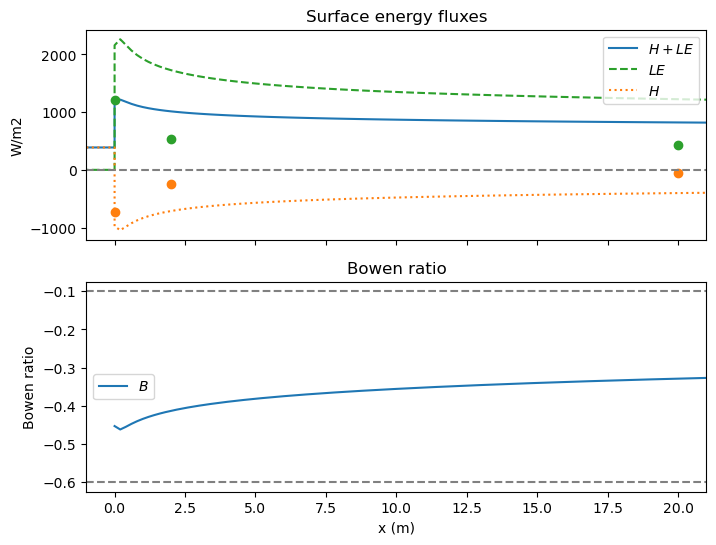

In [39]:
# --- Two-panel figure: surface energy fluxes (top) and Bowen ratio (bottom) ---
_level = level  # use the solver-level value from the main configuration cell
fig, axes = plt.subplots( 2, 1, figsize = (8, 6 ), sharex = True)

# --- Top panel: H, LE, and H+LE along the fetch ---
ax = axes[0]

# Combine upwind (negative x) and downwind (positive x) into a single transect
xx = np.concatenate([-np.flip(x),x])
FluxTotal_ = np.concatenate([FluxTotal_upwind, FluxTotal[:, _level]])

LE_Wm2 = np.concatenate([ LE_upwind_Wm2[_level]*np.ones_like(x), LE_uniform_Wm2[:, _level]])
H_Wm2 = np.concatenate([ H_upwind_Wm2[_level]*np.ones_like(x), H_uniform_Wm2[:, _level]])

# Model curves
ax.plot(xx, FluxTotal_,  c =  'C0', ls = '-', label = '$H + LE$')
ax.plot(xx, LE_Wm2,  ls = '--', c =  'C2',  label = "$LE$")
ax.plot(xx, H_Wm2,  ls = ':', c =  'C1',  label = "$H$")
ax.set_xlim(-1, 21)
ax.legend()

# Rao (1974) Figure 4 reference points (circles) at x = 0, 2, 20 m
ax.plot(2, H_c2, 'C1o')
ax.plot(2, LE_c2, 'C2o')

ax.plot(20, H_c20, 'C1o')
ax.plot(20, LE_c20, 'C2o')

ax.plot(0, H_c0, 'C1o')
ax.plot(0, LE_c0, 'C2o')
ax.set_ylabel("W/m2")
ax.set_title("Surface energy fluxes")
ax.axhline(0, ls = '--', c = 'grey')

# --- Bottom panel: Bowen ratio B = H / LE along the downwind fetch ---
ax = axes[1]
ax.plot(x, (H_uniform_Wm2[:, _level])/LE_uniform_Wm2[:, _level], label = "$B$")
ax.set_title("Bowen ratio")
plt.xlabel("x (m)")
plt.ylabel("Bowen ratio")
# Asymptotic reference lines for B
ax.axhline(-0.1, ls = '--', c = 'grey')
ax.axhline(-0.6, ls = '--', c = 'grey')
plt.legend()


### Flux diagnostics
Sensible and latent heat flux profiles along fetch, Bowen ratio, and energy balance checks.

In [40]:
import re
from pathlib import Path
from typing import Union, Optional

import numpy as np
import pandas as pd

# Matches headers like: "T_x+18.5", "Rao_x-4.63", "T-x+1.15", etc.
_HEADER_PATTERN = re.compile(
    r'^\s*(?P<series>[A-Za-z]+)\s*[_\-]x\s*(?P<sign>[+\-])\s*(?P<xval>\d+(?:\.\d+)?)\s*$')

def parse_rao_wide_to_long(
    data: Union[str, Path, pd.DataFrame],
    start_row: int = 1) -> pd.DataFrame:
    """
    Parse a Rao-style wide digitized table into tidy long format.

    Parameters
    ----------
    data : str | Path | pd.DataFrame
        CSV path or a preloaded DataFrame with paired columns like:
        ['T_x+18.5', 'Unnamed: 1', 'T_x+1.15', 'Unnamed: 3', ...]
        First row contains 'X' (temperature) and 'Y' (height) labels per pair.
    start_row : int
        Row index where numeric data begin (default 1; row 0 = labels).

    Returns
    -------
    pd.DataFrame
        Columns: ['series', 'x', 'T', 'z'] where:
          - series: prefix from header (e.g., 'T', 'Rao')
          - x: horizontal distance (float), signed
          - T: temperature values (from the first-of-pair column)
          - z: vertical height values (from the second-of-pair column)
    """
    # Load input
    if isinstance(data, (str, Path)):
        df_raw = pd.read_csv(data)
    elif isinstance(data, pd.DataFrame):
        df_raw = data.copy()
    else:
        raise TypeError("`data` must be a path or a pandas DataFrame.")

    rows = []
    cols = list(df_raw.columns)
    i = 0
    n = len(cols)

    while i < n:
        col_a = cols[i]
        m = _HEADER_PATTERN.match(str(col_a))
        if m:
            col_b = cols[i + 1] if (i + 1) < n else None

            series = m.group("series")
            sign   = m.group("sign")
            xval   = float(m.group("xval"))
            x = xval if sign == "+" else -xval

            T_vals = pd.to_numeric(df_raw[col_a].iloc[start_row:], errors="coerce").values
            if col_b is not None:
                z_vals = pd.to_numeric(df_raw[col_b].iloc[start_row:], errors="coerce").values
            else:
                z_vals = np.full_like(T_vals, np.nan, dtype=float)

            mlen = min(len(T_vals), len(z_vals))
            T_vals = T_vals[:mlen]
            z_vals = z_vals[:mlen]

            mask = ~(np.isnan(T_vals) & np.isnan(z_vals))
            T_vals = T_vals[mask]
            z_vals = z_vals[mask]

            for Tv, zv in zip(T_vals, z_vals):
                if not (np.isfinite(Tv) or np.isfinite(zv)):
                    continue
                rows.append({"series": series, "x": x, "T": Tv, "z": zv})

            i += 2  # advance past the pair
        else:
            i += 1  # skip non-matching column

    long_df = pd.DataFrame(rows)
    if not long_df.empty:
        long_df = long_df.sort_values(["series", "x", "z"], kind="mergesort").reset_index(drop=True)
    return long_df


# ---- Example usage (no printing, no saving, just DataFrames) ----
fig1_long = parse_rao_wide_to_long("../data/Rao_1974_Figure1.csv")
fig2_long = parse_rao_wide_to_long("../data/Rao_1974_Figure2.csv")



### Validation against Rao (1974)
Load digitised Rider (observed) and Rao (modelled) profiles, overlay on computed T and Q, and compute RMSE tables.

In [41]:
fig1_long

,series,x,T,z
0,Rao,0.00,38.900409,0.011035
1,Rao,0.00,37.668646,0.015161
2,Rao,0.00,34.538626,0.042016
3,Rao,0.00,31.133835,0.462509
4,Rao,0.00,30.082805,9.135594
5,Rao,1.15,30.390386,0.011028
6,Rao,1.15,31.189955,0.016683
7,Rao,1.15,32.824456,0.050589
8,Rao,1.15,31.982259,0.172813
9,Rao,1.15,31.051930,0.512759


In [42]:
# Matches headers like: "Rao_x=18.5", "Rider_x=1.15", "T_x=0", etc.
_WPD_HEADER_PATTERN = re.compile(
    r'^\s*(?P<series>[A-Za-z]+(?:_[A-Za-z]+)*)\s*_x\s*=\s*(?P<xval>-?\d+(?:\.\d+)?)\s*$'
)

def parse_wpd_to_long(
    data: Union[str, Path, pd.DataFrame],
    label_row: int = 1,
    value_col: str = "T",
) -> pd.DataFrame:
    """
    Parse a WebPlotDigitizer (WPD) wide CSV into tidy long format.

    The expected layout is:
      Row 0  : series headers, e.g. 'Rao_x=18.5', '', 'Rider_x=4.63', '', ...
      Row 1  : column-role labels 'X', 'Y', 'X', 'Y', ...  (skipped)
      Row 2+ : numeric data — each pair (col_a, col_b) is (value, z)

    Parameters
    ----------
    data : str | Path | pd.DataFrame
        CSV path or a preloaded DataFrame (header=0 assumed).
    label_row : int
        Index of the X/Y label row to skip (default 1).
    value_col : str
        Name for the value column, e.g. 'T' for temperature or 'Q' for humidity.

    Returns
    -------
    pd.DataFrame
        Columns: ['series', 'x', value_col, 'z'].
    """
    if isinstance(data, (str, Path)):
        df_raw = pd.read_csv(data, header=0)
    elif isinstance(data, pd.DataFrame):
        df_raw = data.copy()
    else:
        raise TypeError("`data` must be a path or a pandas DataFrame.")

    start_row = label_row + 1   # skip the X/Y label row
    rows = []
    cols = list(df_raw.columns)
    n = len(cols)
    i = 0

    while i < n:
        col_a = cols[i]
        m = _WPD_HEADER_PATTERN.match(str(col_a))
        if m:
            col_b = cols[i + 1] if (i + 1) < n else None

            series = m.group("series")
            x      = float(m.group("xval"))

            v_vals = pd.to_numeric(df_raw[col_a].iloc[start_row:], errors="coerce").values
            if col_b is not None:
                z_vals = pd.to_numeric(df_raw[col_b].iloc[start_row:], errors="coerce").values
            else:
                z_vals = np.full_like(v_vals, np.nan, dtype=float)

            mlen   = min(len(v_vals), len(z_vals))
            v_vals = v_vals[:mlen]
            z_vals = z_vals[:mlen]

            mask   = ~(np.isnan(v_vals) & np.isnan(z_vals))
            v_vals = v_vals[mask]
            z_vals = z_vals[mask]

            for vv, zv in zip(v_vals, z_vals):
                if not (np.isfinite(vv) or np.isfinite(zv)):
                    continue
                rows.append({"series": series, "x": x, value_col: vv, "z": zv})

            i += 2  # advance past the (value, z) pair
        else:
            i += 1  # skip unnamed / non-matching column

    long_df = pd.DataFrame(rows)
    if not long_df.empty:
        long_df = long_df.sort_values(["series", "x", "z"], kind="mergesort").reset_index(drop=True)
    return long_df


fig1_long = parse_wpd_to_long("../data/Rao_1974_Figure1_T.csv", value_col="T")
fig2_long = parse_wpd_to_long("../data/Rao_1974_Figure2_Q.csv", value_col="Q")

print(fig2_long.groupby(["series", "x"]).size().rename("n_points").to_string())



series  x    
Rao     0.00     6
        1.15     6
        4.63     6
        18.50    6
Rider   0.00     4
        1.15     4
        4.63     5
        18.50    4


In [43]:

x_panels = [0.0, 1.15, 4.63, 18.5]
ylim_T = (0.045, 2.0); xlim_T = (28, 35)
ylim_Q = (0.04, 2.0);  xlim_Q = (6, 11)

print("=== RIDER T (fig1_long) vs plot bounds  ylim={} xlim={} ===".format(ylim_T, xlim_T))
rider_T = fig1_long[fig1_long['series'] == 'Rider'][['T','z']].apply(pd.to_numeric, errors='coerce').dropna()
rider_T['x'] = fig1_long.loc[rider_T.index, 'x']
for xp in x_panels:
    d = rider_T[rider_T['x'] == xp]
    if len(d) == 0:
        print(f"  x={xp}: NO DATA"); continue
    zmin, zmax = d['z'].min(), d['z'].max()
    tmin, tmax = d['T'].min(), d['T'].max()
    czlo = d[d['z'] < ylim_T[0]]; czhi = d[d['z'] > ylim_T[1]]
    cT   = d[(d['T'] < xlim_T[0]) | (d['T'] > xlim_T[1])]
    print(f"  x={xp} ({len(d)} pts)  z=[{zmin:.4f}, {zmax:.4f}]  T=[{tmin:.2f}, {tmax:.2f}]")
    if len(czlo): print(f"    *** BELOW ylim bottom ({ylim_T[0]}) — clipped from plot: {czlo[['T','z']].values.tolist()}")
    if len(czhi): print(f"    *** ABOVE ylim top ({ylim_T[1]}): {czhi[['T','z']].values.tolist()}")
    if len(cT):   print(f"    *** OUTSIDE xlim {xlim_T}: {cT[['T','z']].values.tolist()}")
    if not len(czlo) and not len(czhi) and not len(cT):
        print(f"    All within bounds")

print("\n=== RIDER Q (fig2_long) vs plot bounds  ylim={} xlim={} ===".format(ylim_Q, xlim_Q))
qcol = 'Q' if 'Q' in fig2_long.columns else 'T'
rider_Q = fig2_long[fig2_long['series'] == 'Rider'][[qcol,'z']].apply(pd.to_numeric, errors='coerce').dropna()
rider_Q['x'] = fig2_long.loc[rider_Q.index, 'x']
for xp in x_panels:
    d = rider_Q[rider_Q['x'] == xp]
    if len(d) == 0:
        print(f"  x={xp}: NO DATA"); continue
    zmin, zmax = d['z'].min(), d['z'].max()
    qmin, qmax = d[qcol].min(), d[qcol].max()
    czlo = d[d['z'] < ylim_Q[0]]; czhi = d[d['z'] > ylim_Q[1]]
    cQ   = d[(d[qcol] < xlim_Q[0]) | (d[qcol] > xlim_Q[1])]
    print(f"  x={xp} ({len(d)} pts)  z=[{zmin:.4f}, {zmax:.4f}]  Q=[{qmin:.2f}, {qmax:.2f}]")
    if len(czlo): print(f"    *** BELOW ylim bottom ({ylim_Q[0]}) — clipped from plot: {czlo[[qcol,'z']].values.tolist()}")
    if len(czhi): print(f"    *** ABOVE ylim top ({ylim_Q[1]}): {czhi[[qcol,'z']].values.tolist()}")
    if len(cQ):   print(f"    *** OUTSIDE xlim {xlim_Q}: {cQ[[qcol,'z']].values.tolist()}")
    if not len(czlo) and not len(czhi) and not len(cQ):
        print(f"    All within bounds")


=== RIDER T (fig1_long) vs plot bounds  ylim=(0.045, 2.0) xlim=(28, 35) ===
  x=0.0 (4 pts)  z=[0.0501, 0.6406]  T=[30.73, 33.95]
    All within bounds
  x=1.15 (4 pts)  z=[0.0496, 0.6346]  T=[30.73, 32.56]
    All within bounds
  x=4.63 (4 pts)  z=[0.0505, 0.6406]  T=[30.56, 31.19]
    All within bounds
  x=18.5 (4 pts)  z=[0.0496, 0.6226]  T=[29.05, 29.85]
    All within bounds

=== RIDER Q (fig2_long) vs plot bounds  ylim=(0.04, 2.0) xlim=(6, 11) ===
  x=0.0 (4 pts)  z=[0.0467, 0.6120]  Q=[6.34, 6.44]
    All within bounds
  x=1.15 (4 pts)  z=[0.0475, 0.6120]  Q=[6.44, 8.07]
    All within bounds
  x=4.63 (5 pts)  z=[0.0467, 0.6120]  Q=[6.44, 9.10]
    All within bounds
  x=18.5 (4 pts)  z=[0.0467, 0.6225]  Q=[7.04, 10.22]
    All within bounds


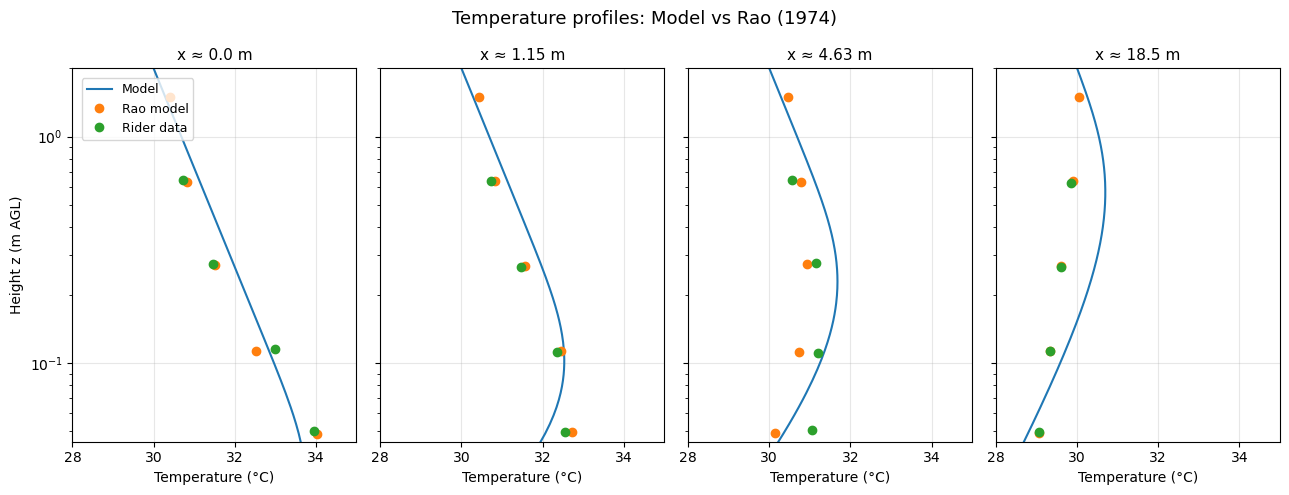

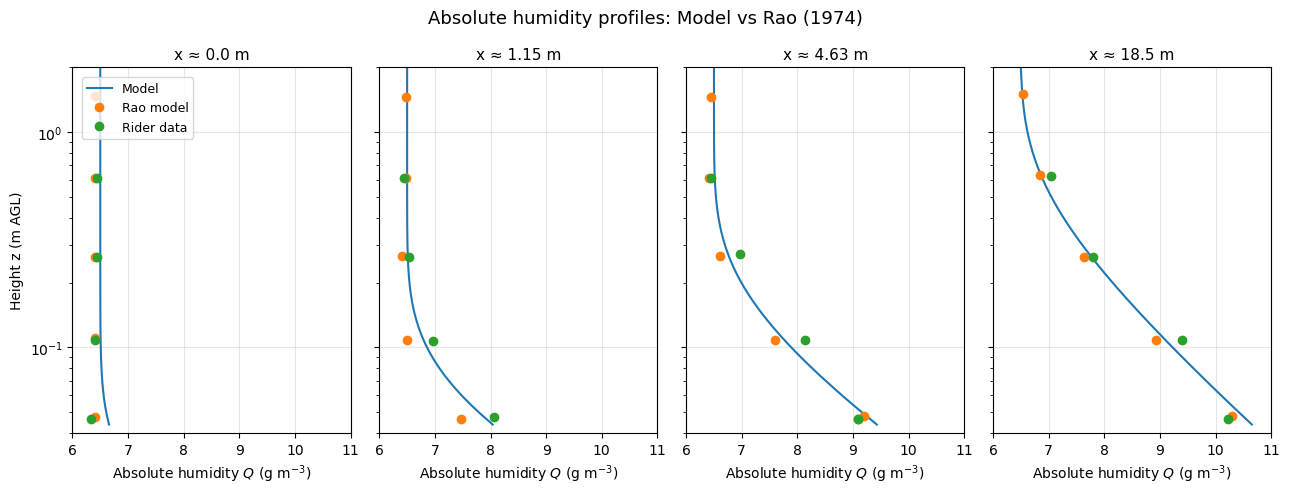

In [44]:
LOG_Y = True

# --------- T profiles (digitized Fig. 1 vs model T_uniform) ---------
fig, axes = plt.subplots(1, 4, figsize=(13, 5), sharey=True)
fig.suptitle("Temperature profiles: Model vs Rao (1974)", fontsize=13)

ind0 = np.where(p.z > 0.04)[0][0]

for ax, x_plot in zip(axes, x_panels):
    ind = np.argmin(np.abs(p.x - x_plot))

    ax.plot(T_uniform[ind][ind0:], p.z[ind0:] + p.d_c, label="Model")

    d1 = fig1_long.query(f"x == {x_plot} and series == 'Rao'")
    ax.plot(d1["T"], d1["z"], "o", label="Rao model")

    d1 = fig1_long.query(f"x == {x_plot} and series == 'Rider'")
    ax.plot(d1["T"], d1["z"], "o", label="Rider data")

    ax.set_title(f"x ≈ {x_plot} m", fontsize=11)
    ax.set_xlabel("Temperature (°C)", fontsize=10)
    ax.set_xlim(xlim_T)
    ax.set_ylim(ylim_T)
    ax.set_yscale("log" if LOG_Y else "linear")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Height z (m AGL)", fontsize=10)
axes[0].legend(loc="upper left", bbox_to_anchor=(0.01, 0.99), fontsize=9)
plt.tight_layout()


# --------- Q profiles (digitized Fig. 2 vs model Q_uniform) ---------
fig, axes = plt.subplots(1, 4, figsize=(13, 5), sharey=True)
fig.suptitle("Absolute humidity profiles: Model vs Rao (1974)", fontsize=13)

for ax, x_plot in zip(axes, x_panels):
    ind = np.argmin(np.abs(p.x - x_plot))

    ax.plot(Q_uniform[ind][ind0:], p.z[ind0:] + p.d_c, "-", label="Model")

    # Rao digitized profile
    d1 = fig2_long.query(f"x == {x_plot} and series == 'Rao'")
    ax.plot(d1["Q"], d1["z"], "o", label="Rao model")

    # Rider digitized profile
    d1 = fig2_long.query(f"x == {x_plot} and series == 'Rider'")
    ax.plot(d1["Q"], d1["z"], "o", label="Rider data")

    ax.set_title(f"x ≈ {x_plot} m", fontsize=11)
    ax.set_xlabel(r"Absolute humidity $Q$ (g m$^{-3}$)", fontsize=10)
    ax.set_xlim(xlim_Q)
    ax.set_ylim(ylim_Q)
    ax.set_yscale("log" if LOG_Y else "linear")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Height z (m AGL)", fontsize=10)
axes[0].legend(loc="upper left", bbox_to_anchor=(0.01, 0.99), fontsize=9)
plt.tight_layout()


In [45]:
import numpy as np

def profile_rmse(profile_a, z_a, profile_b, z_b):
    """Interpolate profile_a onto z_b and return RMSE vs profile_b."""
    z_a = np.asarray(z_a)
    profile_a = np.asarray(profile_a)

    order = np.argsort(z_a)
    a_at_b = np.interp(z_b, z_a[order], profile_a[order])
    return np.sqrt(np.mean((a_at_b - profile_b) ** 2))


# x-locations to compare (same as plots: 0, 1.15, 4.63, 18.5 m)
x_locs = [0.0, 1.15, 4.63, 18.5]

rmse_T_vs_model = []
rmse_T_vs_rao   = []
rmse_Q_vs_model = []
rmse_Q_vs_rao   = []

# ---------- T profiles: Rider vs model, Rider vs Rao ----------
for x_plot in x_locs:
    ind = np.argmin(np.abs(p.x - x_plot))
    model_z = p.z + p.d_c
    model_T = T_uniform[ind]

    d_rider = fig1_long.query(f"x == {x_plot} and series == 'Rider'")
    rider_z = d_rider["z"].values[:]
    rider_T = d_rider["T"].values[:]

    d_rao = fig1_long.query(f"x == {x_plot} and series == 'Rao'")
    rao_z = d_rao["z"].values[:]
    rao_T = d_rao["T"].values[:]

    rmse_T_vs_model.append(profile_rmse(model_T, model_z, rider_T, rider_z))
    rmse_T_vs_rao.append(profile_rmse(rao_T, rao_z, rider_T, rider_z))

# ---------- Q profiles: Rider vs model, Rider vs Rao ----------
for x_plot in x_locs:
    ind = np.argmin(np.abs(p.x - x_plot))
    model_z = p.z + p.d_c
    model_Q = Q_uniform[ind]

    d_rider = fig2_long.query(f"x == {x_plot} and series == 'Rider'")
    rider_z = d_rider["z"].values[:]
    rider_Q = d_rider["Q"].values[:]

    d_rao = fig2_long.query(f"x == {x_plot} and series == 'Rao'")
    rao_z = d_rao["z"].values[:]
    rao_Q = d_rao["Q"].values[:]

    rmse_Q_vs_model.append(profile_rmse(model_Q, model_z, rider_Q, rider_z))
    rmse_Q_vs_rao.append(profile_rmse(rao_Q, rao_z, rider_Q, rider_z))


# ---------- Pretty-print tables ----------
header = "x (m)            " + "  ".join(f"{x:7.2f}" for x in x_locs) + "     mean"

print("Temperature RMSE (Rider vs ...):")
print(header)
print("  Rider vs Sutton" + "  ".join(f"{v:7.3f}" for v in rmse_T_vs_model) + f"  {np.mean(rmse_T_vs_model):7.3f}")
print("  Rider vs Rao   " + "  ".join(f"{v:7.3f}" for v in rmse_T_vs_rao) + f"  {np.mean(rmse_T_vs_rao):7.3f}")

print("\nAbsolute humidity RMSE (Rider vs ...):")
print(header)
print("  Rider vs Sutton" + "  ".join(f"{v:7.3f}" for v in rmse_Q_vs_model) + f"  {np.mean(rmse_Q_vs_model):7.3f}")
print("  Rider vs Rao   " + "  ".join(f"{v:7.3f}" for v in rmse_Q_vs_rao) + f"  {np.mean(rmse_Q_vs_rao):7.3f}")

Temperature RMSE (Rider vs ...):
x (m)               0.00     1.15     4.63    18.50     mean
  Rider vs Sutton  0.379    0.411    0.499    0.632    0.480
  Rider vs Rao     0.240    0.117    0.530    0.024    0.228

Absolute humidity RMSE (Rider vs ...):
x (m)               0.00     1.15     4.63    18.50     mean
  Rider vs Sutton  0.160    0.126    0.237    0.236    0.190
  Rider vs Rao     0.040    0.381    0.322    0.276    0.255


In [ ]:
import numpy as np
import pandas as pd
from itertools import product

# --- RMSE helper ---
def profile_rmse(model_profile, model_z, rider_vals, rider_z):
    """Interpolate model profile to Rider z and return RMSE."""
    model_z = np.asarray(model_z)
    model_profile = np.asarray(model_profile)
    if len(rider_z) == 0 or len(rider_vals) == 0:
        return np.nan
    order = np.argsort(model_z)
    mp_at_rz = np.interp(rider_z, model_z[order], model_profile[order])
    return np.sqrt(np.mean((mp_at_rz - rider_vals) ** 2))


def compute_rmse_for_case(p, T_uniform, Q_uniform,
                          x_locs=(0.0, 1.15, 4.63, 18.5)):
    """RMSE arrays for T and Q at given x locations."""
    rmse_T, rmse_Q = [], []
    z_model = p.z + p.d_c

    for x_plot in x_locs:
        ix = np.argmin(np.abs(p.x - x_plot))

        d1 = fig1_long.query(f"x == {x_plot} and series == 'Rider'")
        rmse_T.append(profile_rmse(T_uniform[ix], z_model,
                                   d1["T"].values[:-1], d1["z"].values[:-1]))

        d2 = fig2_long.query(f"x == {x_plot} and series == 'Rider'")
        rmse_Q.append(profile_rmse(Q_uniform[ix], z_model,
                                   d2["Q"].values[:-1], d2["z"].values[:-1]))

    return np.array(rmse_T), np.array(rmse_Q)


# ----------------------------------------------------------------
#  Refined sweep — uses the SAME pipeline as the main run (cell 13)
# ----------------------------------------------------------------
def sweep_refined(
    ustar_f_values,
    avail_ratio_values,
    le_factor_values,
    Q_a_values,
    lm_zshift_values=(0.0005,),
    zom_c_values=(0.0005,),
    shear_ratio: float = 1.0,
    x_locs=(0.0, 1.15, 4.63, 18.5),
):
    """
    Sweep over (ustar_f, avail_ratio, le_factor, Q_a, lm_zshift, zom_c)
    using the full main-run pipeline:
        solve_surface_radiation_inplace(fix='alpha_c')
        update_surface_BCs_from_reference(update_T=True, update_Q=True)
        sync_surface_moisture_inplace('RH_from_Q')
        reconcile_heat_with_prescribed_surface_T(mode='update_ustar', ref='z_ref')
        update_surface_BCs_from_reference(update_T=True, update_Q=True)
    """
    rows = []
    combos = list(product(ustar_f_values, avail_ratio_values, le_factor_values,
                          Q_a_values, lm_zshift_values, zom_c_values))
    print(f"Running {len(combos)} combinations ...")

    for ustar_f, avail_ratio, le_factor, Q_a, lm_zshift, zom_c in combos:
        ustar_c = ustar_f * np.sqrt(shear_ratio)

        try:
            pp = AdvectionParams(
                ustar_f=ustar_f, ustar_c=ustar_c,
                lm_option='kz', lm_zshift=lm_zshift, zom_c=zom_c,
                avail_ratio=avail_ratio, le_factor=le_factor,
                Hmax=2.0, dz=0.005, dx=0.2,
                Q_a=Q_a, Q_f=Q_a, tie_Qa_to_Qf=True,
            )

            # --- main-run pipeline (matches cell 13) ---
            pp.solve_surface_radiation_inplace(fix="alpha_c")
            pp.update_surface_BCs_from_reference(update_T=True, update_Q=True)
            pp.sync_surface_moisture_inplace("RH_from_Q")
            pp.reconcile_heat_with_prescribed_surface_T(
                mode="update_ustar", ref="z_ref")
            pp.update_surface_BCs_from_reference(update_T=True, update_Q=True)

            _T, _ = uniform_T(pp)
            _Q, _ = uniform_Q(pp)

            rmse_T, rmse_Q = compute_rmse_for_case(pp, _T, _Q, x_locs)

        except Exception as e:
            rmse_T = np.full(len(x_locs), np.nan)
            rmse_Q = np.full(len(x_locs), np.nan)

        x_cols = [f"x={float(x):.2f}" for x in x_locs]
        row = dict(ustar_f=ustar_f, avail_ratio=avail_ratio,
                   le_factor=le_factor, Q_a=Q_a,
                   lm_zshift=lm_zshift, zom_c=zom_c)
        for xc, rt, rq in zip(x_cols, rmse_T, rmse_Q):
            row[f"T_{xc}"] = rt
            row[f"Q_{xc}"] = rq
        rows.append(row)

    df = pd.DataFrame(rows)
    param_cols = ["ustar_f", "avail_ratio", "le_factor", "Q_a", "lm_zshift", "zom_c"]
    T_cols = [c for c in df.columns if c.startswith("T_x=")]
    Q_cols = [c for c in df.columns if c.startswith("Q_x=")]
    df["T_mean"] = df[T_cols].mean(axis=1)
    df["Q_mean"] = df[Q_cols].mean(axis=1)
    df["combined"] = 0.5 * df["T_mean"] + 0.5 * df["Q_mean"]
    df = df.set_index(param_cols)
    return df


# ----------------------------------------------------------------
#  Run the sweep — fine grids centred on current best
# ----------------------------------------------------------------
ustar_vals  = [0.6, 0.7, 0.8, 0.9, 1.0]
avail_vals  = [1.2, 1.3, 1.4, 1.5, 1.6]
le_vals     = [1.2, 1.3, 1.4, 1.5, 1.6]
Q_a_vals    = [5.5, 6.0, 6.3, 6.5, 7.0]
lm_shifts   = [0.0005]
zom_vals    = [0.0005]

df_sweep = sweep_refined(
    ustar_vals, avail_vals, le_vals, Q_a_vals,
    lm_zshift_values=lm_shifts, zom_c_values=zom_vals,
)
print(f"\nTotal combos evaluated: {len(df_sweep)}")
print(f"\n--- Best 10 by combined (0.5*T + 0.5*Q) ---")
print(df_sweep.sort_values("combined").head(10)[["T_mean", "Q_mean", "combined"]].to_string(float_format="%.3f"))

Running 625 combinations ...


In [ ]:
# ── Fine-grid sweep around the best region from pass 1 ──
ustar_fine  = [0.65, 0.70, 0.75, 0.80]
avail_fine  = [1.4, 1.5, 1.6, 1.7, 1.8]
le_fine     = [1.3, 1.35, 1.4, 1.45, 1.5]
Qa_fine     = [6.3, 6.5, 6.7, 7.0]

df_fine = sweep_refined(
    ustar_fine, avail_fine, le_fine, Qa_fine,
    lm_zshift_values=[0.0005],
    zom_c_values=[0.0005],
)

print(f"\nTotal combos evaluated: {len(df_fine)}")
print(f"\n--- Best 15 by combined (0.5*T + 0.5*Q) ---")
print(df_fine.sort_values("combined").head(15)[["T_mean", "Q_mean", "combined"]].to_string(float_format="%.3f"))

# Also show best by T alone and best by Q alone
print(f"\n--- Best 5 by T_mean ---")
print(df_fine.sort_values("T_mean").head(5)[["T_mean", "Q_mean", "combined"]].to_string(float_format="%.3f"))

print(f"\n--- Best 5 by Q_mean ---")
print(df_fine.sort_values("Q_mean").head(5)[["T_mean", "Q_mean", "combined"]].to_string(float_format="%.3f"))

Running 400 combinations ...

Total combos evaluated: 400

--- Best 15 by combined (0.5*T + 0.5*Q) ---
                                                    T_mean  Q_mean  combined
ustar_f avail_ratio le_factor Q_a lm_zshift zom_c                           
0.75    1.8         1.30      6.5 0.0005    0.0005   0.451   0.213     0.332
                    1.35      6.5 0.0005    0.0005   0.455   0.210     0.332
        1.7         1.35      6.5 0.0005    0.0005   0.450   0.221     0.336
        1.6         1.35      6.7 0.0005    0.0005   0.449   0.222     0.336
        1.7         1.30      6.7 0.0005    0.0005   0.455   0.219     0.337
0.80    1.8         1.30      6.7 0.0005    0.0005   0.455   0.219     0.337
0.75    1.6         1.40      6.7 0.0005    0.0005   0.457   0.220     0.338
        1.7         1.40      6.5 0.0005    0.0005   0.468   0.210     0.339
                    1.35      6.7 0.0005    0.0005   0.450   0.228     0.339
0.80    1.7         1.35      6.7 0.0005    0.0005

### Parameter sensitivity
Grid search over `lm_zshift` and `ustar_f` to find best-fit parameters.

In [ ]:
df_fine.sort_values('combined').head(10)

T_x=0.00  Q_x=0.00  \
ustar_f avail_ratio le_factor Q_a lm_zshift zom_c                        
0.75    1.8         1.30      6.5 0.0005    0.0005  0.371908  0.179157   
                    1.35      6.5 0.0005    0.0005  0.374720  0.181839   
        1.7         1.35      6.5 0.0005    0.0005  0.373622  0.177818   
        1.6         1.35      6.7 0.0005    0.0005  0.372530  0.358380   
        1.7         1.30      6.7 0.0005    0.0005  0.370979  0.359631   
0.80    1.8         1.30      6.7 0.0005    0.0005  0.452685  0.359224   
0.75    1.6         1.40      6.7 0.0005    0.0005  0.375034  0.360384   
        1.7         1.40      6.5 0.0005    0.0005  0.376297  0.180348   
                    1.35      6.7 0.0005    0.0005  0.373622  0.361765   
0.80    1.7         1.35      6.7 0.0005    0.0005  0.454782  0.358169   

                                                    T_x=1.15  Q_x=1.15  \
ustar_f avail_ratio le_factor Q_a lm_zshift zom_c                        
0.75    1.8         1.30      6.5 0.0005    0.0005  0.383064  0.168610   
                    1.35      6.5 0.0005    0.0005  0.414526  0.141861   
        1.7         1.35      6.5 0.0005    0.0005  0.401610  0.182412   
        1.6         1.35      6.7 0.0005    0.0005  0.389545  0.125294   
        1.7         1.30      6.7 0.0005    0.0005  0.373948  0.116112   
0.80    1.8         1.30      6.7 0.0005    0.0005  0.372373  0.118911   
0.75    1.6         1.40      6.7 0.0005    0.0005  0.418362  0.111471   
        1.7         1.40      6.5 0.0005    0.0005  0.434303  0.156558   
                    1.35      6.7 0.0005    0.0005  0.401610  0.104985   
0.80    1.7         1.35      6.7 0.0005    0.0005  0.398198  0.126999   

                                                    T_x=4.63  Q_x=4.63  \
ustar_f avail_ratio le_factor Q_a lm_zshift zom_c                        
0.75    1.8         1.30      6.5 0.0005    0.0005  0.421721  0.250701   
                    1.35      6.5 0.0005    0.0005  0.481945  0.261919   
        1.7         1.35      6.5 0.0005    0.0005  0.455348  0.253846   
        1.6         1.35      6.7 0.0005    0.0005  0.432671  0.173127   
        1.7         1.30      6.7 0.0005    0.0005  0.408348  0.181978   
0.80    1.8         1.30      6.7 0.0005    0.0005  0.381036  0.178021   
0.75    1.6         1.40      6.7 0.0005    0.0005  0.490177  0.191740   
        1.7         1.40      6.5 0.0005    0.0005  0.525544  0.252859   
                    1.35      6.7 0.0005    0.0005  0.455348  0.216535   
0.80    1.7         1.35      6.7 0.0005    0.0005  0.423255  0.172641   

                                                    T_x=18.50  Q_x=18.50  \
ustar_f avail_ratio le_factor Q_a lm_zshift zom_c                          
0.75    1.8         1.30      6.5 0.0005    0.0005   0.625862   0.254284   
                    1.35      6.5 0.0005    0.0005   0.546995   0.255134   
        1.7         1.35      6.5 0.0005    0.0005   0.569935   0.270021   
        1.6         1.35      6.7 0.0005    0.0005   0.603010   0.230210   
        1.7         1.30      6.7 0.0005    0.0005   0.664749   0.216929   
0.80    1.8         1.30      6.7 0.0005    0.0005   0.613784   0.219599   
0.75    1.6         1.40      6.7 0.0005    0.0005   0.542496   0.216426   
        1.7         1.40      6.5 0.0005    0.0005   0.534276   0.249129   
                    1.35      6.7 0.0005    0.0005   0.569935   0.230124   
0.80    1.7         1.35      6.7 0.0005    0.0005   0.554475   0.233850   

                                                      T_mean    Q_mean  \
ustar_f avail_ratio le_factor Q_a lm_zshift zom_c                        
0.75    1.8         1.30      6.5 0.0005    0.0005  0.450639  0.213188   
                    1.35      6.5 0.0005    0.0005  0.454546  0.210188   
        1.7         1.35      6.5 0.0005    0.0005  0.450129  0.221024   
        1.6         1.35      6.7 0.0005    0.0005  0.449439  0.221753   
        1.7         1.30    

In [ ]:
df_fine.sort_values('Q_mean').head(10)

T_x=0.00  Q_x=0.00  \
ustar_f avail_ratio le_factor Q_a lm_zshift zom_c                        
0.70    1.6         1.40      6.5 0.0005    0.0005  0.376231  0.180945   
0.75    1.6         1.50      6.5 0.0005    0.0005  0.380128  0.180945   
0.65    1.6         1.30      6.5 0.0005    0.0005  0.498325  0.180945   
0.80    1.7         1.50      6.5 0.0005    0.0005  0.464578  0.180665   
0.70    1.5         1.50      6.5 0.0005    0.0005  0.377534  0.181264   
0.75    1.7         1.40      6.5 0.0005    0.0005  0.376297  0.180348   
0.65    1.4         1.50      6.5 0.0005    0.0005  0.495699  0.181633   
        1.5         1.40      6.5 0.0005    0.0005  0.496852  0.181633   
0.75    1.8         1.35      6.5 0.0005    0.0005  0.374720  0.181839   
0.70    1.7         1.30      6.5 0.0005    0.0005  0.374812  0.179987   

                                                    T_x=1.15  Q_x=1.15  \
ustar_f avail_ratio le_factor Q_a lm_zshift zom_c                        
0.70    1.6         1.40      6.5 0.0005    0.0005  0.468960  0.150624   
0.75    1.6         1.50      6.5 0.0005    0.0005  0.487036  0.150624   
0.65    1.6         1.30      6.5 0.0005    0.0005  0.583943  0.150624   
0.80    1.7         1.50      6.5 0.0005    0.0005  0.528275  0.153397   
0.70    1.5         1.50      6.5 0.0005    0.0005  0.497852  0.147474   
0.75    1.7         1.40      6.5 0.0005    0.0005  0.434303  0.156558   
0.65    1.4         1.50      6.5 0.0005    0.0005  0.581114  0.143867   
        1.5         1.40      6.5 0.0005    0.0005  0.576797  0.143867   
0.75    1.8         1.35      6.5 0.0005    0.0005  0.414526  0.141861   
0.70    1.7         1.30      6.5 0.0005    0.0005  0.448861  0.160192   

                                                    T_x=4.63  Q_x=4.63  \
ustar_f avail_ratio le_factor Q_a lm_zshift zom_c                        
0.70    1.6         1.40      6.5 0.0005    0.0005  0.533308  0.255661   
0.75    1.6         1.50      6.5 0.0005    0.0005  0.649243  0.255661   
0.65    1.6         1.30      6.5 0.0005    0.0005  0.563819  0.255661   
0.80    1.7         1.50      6.5 0.0005    0.0005  0.687359  0.254208   
0.70    1.5         1.50      6.5 0.0005    0.0005  0.627791  0.257619   
0.75    1.7         1.40      6.5 0.0005    0.0005  0.525544  0.252859   
0.65    1.4         1.50      6.5 0.0005    0.0005  0.635119  0.260263   
        1.5         1.40      6.5 0.0005    0.0005  0.577299  0.260263   
0.75    1.8         1.35      6.5 0.0005    0.0005  0.481945  0.261919   
0.70    1.7         1.30      6.5 0.0005    0.0005  0.474147  0.251713   

                                                    T_x=18.50  Q_x=18.50  \
ustar_f avail_ratio le_factor Q_a lm_zshift zom_c                          
0.70    1.6         1.40      6.5 0.0005    0.0005   0.570513   0.249880   
0.75    1.6         1.50      6.5 0.0005    0.0005   0.601768   0.249880   
0.65    1.6         1.30      6.5 0.0005    0.0005   0.743388   0.249880   
0.80    1.7         1.50      6.5 0.0005    0.0005   0.599790   0.249250   
0.70    1.5         1.50      6.5 0.0005    0.0005   0.610342   0.251196   
0.75    1.7         1.40      6.5 0.0005    0.0005   0.534276   0.249129   
0.65    1.4         1.50      6.5 0.0005    0.0005   0.628239   0.253492   
        1.5         1.40      6.5 0.0005    0.0005   0.616911   0.253492   
0.75    1.8         1.35      6.5 0.0005    0.0005   0.546995   0.255134   
0.70    1.7         1.30      6.5 0.0005    0.0005   0.680052   0.249763   

                                                      T_mean    Q_mean  \
ustar_f avail_ratio le_factor Q_a lm_zshift zom_c                        
0.70    1.6         1.40      6.5 0.0005    0.0005  0.487253  0.209277   
0.75    1.6         1.50      6.5 0.0005    0.0005  0.529544  0.209277   
0.65    1.6         1.30      6.5 0.0005    0.0005  0.597369  0.209277   
0.80    1.7         1.50      6.5 0.0005    0.0005  0.570000  0.209380   
0.70    1.5         1.50    

In [ ]:

# zmin = zom + d 
# adjust 
# 5 cm
# predict flux. 
# z = zmin ... zmax


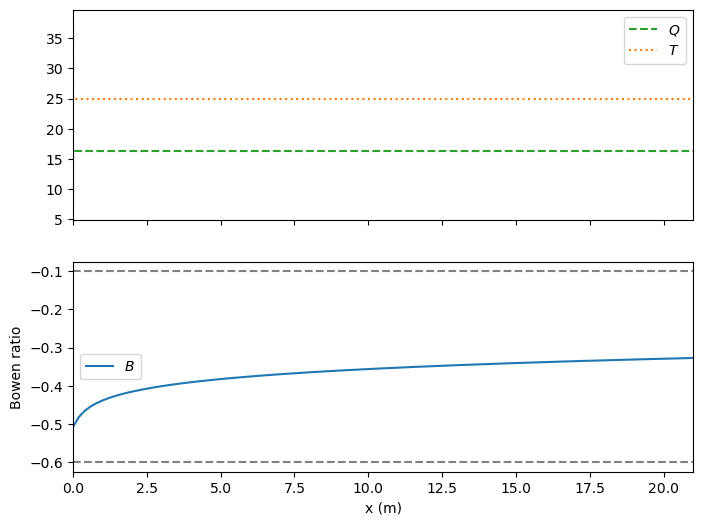

In [ ]:
fig, axes = plt.subplots( 2, 1, figsize = (8, 6 ), sharex = True)
ax = axes[0]
xx =  np.concatenate([-np.flip(x),x])
# FluxTotal_ = np.concatenate([FluxTotal_upwind, FluxTotal[:, level]])

_level = 0  # surface-level diagnostics
Q = np.concatenate([ Q_up[_level]*np.ones_like(x), Q_uniform[:, _level]])
T = np.concatenate([ T_up[_level]*np.ones_like(x), T_uniform[:, _level]])

ax.plot(xx[1:], (Q[1:]),  ls = '--', c =  'C2',  label = "$Q$")
ax.plot(xx[1:], (T[1:]),  ls = ':', c =  'C1',  label = "$T$")
ax.set_xlim(0, 21)

# ax.set_yscale('log')
ax.legend()

ax = axes[1]
x = p.x

ax.plot(x, (H_uniform_Wm2[:, _level])/LE_uniform_Wm2[:, _level], label = "$B$")
plt.xlabel("x (m)")
plt.ylabel("Bowen ratio")
ax.axhline(-0.1, ls = '--', c = 'grey')
ax.axhline(-0.6, ls = '--', c = 'grey')

plt.legend()
# Sensible heat flux needs to move to 0 faster than LE moves to LE_c? 

### Surface-level T, Q, and Bowen ratio along fetch

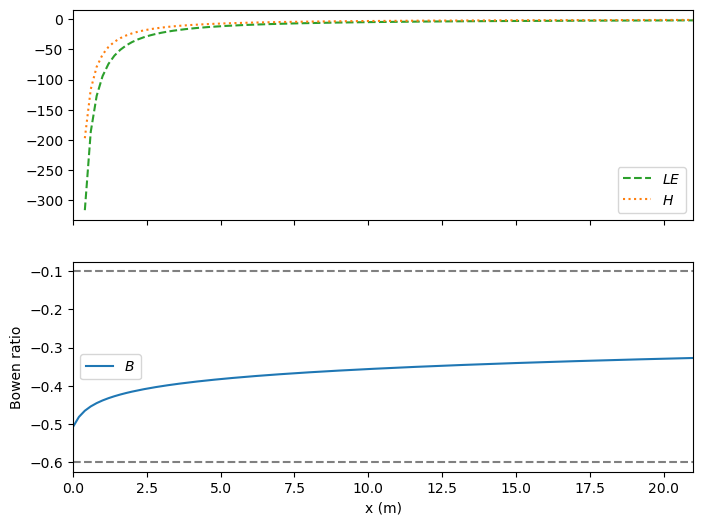

In [ ]:
_level = 0  # surface fluxes
fig, axes = plt.subplots( 2, 1, figsize = (8, 6 ), sharex = True)
ax = axes[0]

xx = np.concatenate([-np.flip(x),x])
FluxTotal_ = np.concatenate([FluxTotal_upwind, FluxTotal[:, _level]])

LE_Wm2 = np.concatenate([ LE_upwind_Wm2[_level]*np.ones_like(x), LE_uniform_Wm2[:, _level]])
H_Wm2 = np.concatenate([ H_upwind_Wm2[_level]*np.ones_like(x), H_uniform_Wm2[:, _level]])

ax.plot(p.x[2:], np.diff(LE_uniform_Wm2[1:,_level]),  ls = '--', c =  'C2',  label = "$LE$")
ax.plot(p.x[2:], - np.diff(H_uniform_Wm2[1:, _level]),  ls = ':', c =  'C1',  label = "$H$")
ax.set_xlim(0, 21)

# ax.set_yscale('log')
ax.legend()

ax = axes[1]
x = p.x

ax.plot(x, (H_uniform_Wm2[:, _level])/LE_uniform_Wm2[:, _level], label = "$B$")
plt.xlabel("x (m)")
plt.ylabel("Bowen ratio")
ax.axhline(-0.1, ls = '--', c = 'grey')
ax.axhline(-0.6, ls = '--', c = 'grey')

plt.legend()
# Sensible heat flux needs to move to 0 faster than LE moves to LE_c? 

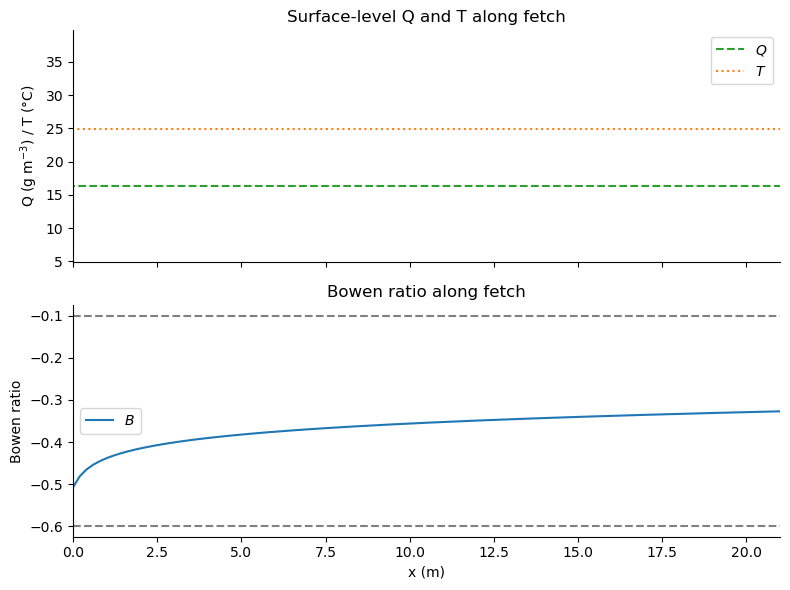

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

xx = np.concatenate([-np.flip(x), x])

_level = 0  # surface-level T, Q, and Bowen ratio
Q = np.concatenate([Q_up[_level] * np.ones_like(x), Q_uniform[:, _level]])
T = np.concatenate([T_up[_level] * np.ones_like(x), T_uniform[:, _level]])

# --- top panel: Q and T at surface level ---
ax = axes[0]
ax.plot(xx[1:], Q[1:], ls='--', c='C2', label="$Q$")
ax.plot(xx[1:], T[1:], ls=':', c='C1', label="$T$")
ax.set_xlim(0, 21)
ax.set_ylabel("Q (g m$^{-3}$) / T (°C)")
ax.set_title("Surface-level Q and T along fetch")
ax.legend()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# --- bottom panel: Bowen ratio ---
ax = axes[1]
ax.plot(p.x, H_uniform_Wm2[:, _level] / LE_uniform_Wm2[:, _level], label="$B$")
ax.axhline(-0.1, ls='--', c='grey')
ax.axhline(-0.6, ls='--', c='grey')
ax.set_xlabel("x (m)")
ax.set_ylabel("Bowen ratio")
ax.set_title("Bowen ratio along fetch")
ax.legend()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

In [ ]:
# Upwind checks

H_wall_Wm2  =  p.ustar_f * p.k * (p.T_sf - p.T_a) / np.log(p.Hmax / p.z[0]) * rho_air *cp_air

print("H_f (AdvectionParams):       ", p.H_f)
print("H_wall:              {0:.2f}".format( H_wall_Wm2) ) 


# Downwind checks
# Lv_g = 2430.0  # J g^-1
Fq_wall_gm2s = p.ustar_c * p.k * (p.Q_c - p.Q_a) / np.log(p.Hmax / p.z[0])
LE_wall_Wm2  = Fq_wall_gm2s * Lv_g

print("\nLE_c (AdvectionParams):      ", p.LE_c)
print("LE_wall:             {0:.2f} ".format(LE_wall_Wm2))  


H_f (AdvectionParams):        355.64
H_wall:              355.64

LE_c (AdvectionParams):       864.2052000000001
LE_wall:             864.21 


\begin{aligned}
\mathrm{SW}\,(1-\alpha_f) + \varepsilon_a \,\sigma_{SB}\, T_a^{4}
  - \varepsilon_f \,\sigma_{SB}\, T_{sf}^{4} &= R_{n,f}, \\
\mathrm{SW}\,(1-\alpha_c) + \varepsilon_a \,\sigma_{SB}\, T_a^{4}
  - \varepsilon_c \,\sigma_{SB}\, T_{sc}^{4} &= R_{n,c}, \\
T_{sf} - T_a &= \frac{1}{k\,u_{*f}}\,
  \frac{H_f}{\rho\,c_p}\,
  \ln\!\left(\frac{z_h}{z_\ell}\right), \\
T_{sc} - T_a &= \frac{1}{k\,u_{*c}}\,
  \frac{H_c}{\rho\,c_p}\,
  \ln\!\left(\frac{z_h}{z_\ell}\right), \\
Q_c - Q_a &= \frac{1}{k\,u_{*c}}\,
  \frac{\mathrm{LE}_c}{L_v}\,
  \ln\!\left(\frac{z_h}{z_\ell}\right), \\
R_{n,c} - G &= \mathrm{LE}_c + H_c .
\end{aligned}

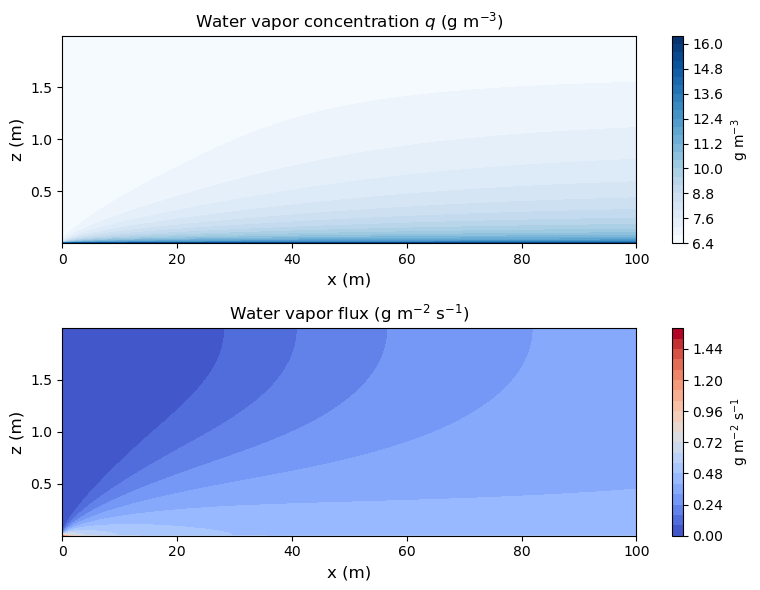

In [ ]:
z = p.z
x = p.x

# Plot water vapor concentration and vertical flux
plt.figure(figsize = (8, 6))

plt.subplot(2, 1, 1)
nz = Q_uniform.shape[1]
plt.contourf(x, z[:nz], (Q_uniform.T), 25, cmap='Blues',  vmax = p.Q_c, vmin =p.Q_a)
plt.colorbar(label='g m$^{-3}$')
plt.xlabel('x (m)', fontsize=12, fontweight='normal')
plt.ylabel('z (m)', fontsize=12, fontweight='normal')
plt.title('Water vapor concentration $q$ (g m$^{-3}$)', fontsize=12)

plt.subplot(2, 1, 2)
plt.contourf(x, z[:nz], FluxQ_uniform.T.round(4),  20, cmap='coolwarm', vmin = 0, vmax = FluxQ_uniform.max())
plt.colorbar(label='g m$^{-2}$ s$^{-1}$') 
plt.xlabel('x (m)', fontsize=12, fontweight='normal')
plt.ylabel('z (m)', fontsize=12, fontweight='normal')
plt.title('Water vapor flux (g m$^{-2}$ s$^{-1}$)', fontsize=12)
plt.tight_layout()



### 2-D fields
Contour plots of Q and vertical moisture flux across the (x, z) domain.

In [ ]:

_level = 1  # first interior grid point for rough estimate
# rough estimate at level height z:
z_eff = z[_level] - p.h_c*2/3
lm    = p.k * z_eff  
K     = lm * ustar_c
U = (p.ustar_f / p.k) * np.log(z / p.zom_c) 
Lrec  = U[_level] * z_eff / (p.k * ustar_c)   

In [ ]:
Q_uniform.shape, p.z.shape

((501, 400), (400,))

[-977.95174278 -875.38297657 -713.80495512 -603.36283741]
SH(x) ≈ -461.19 + (-516.76) * exp(-x/3.03)
LH(x) ≈ 1329.01 + (829.68) * exp(-x/2.95)


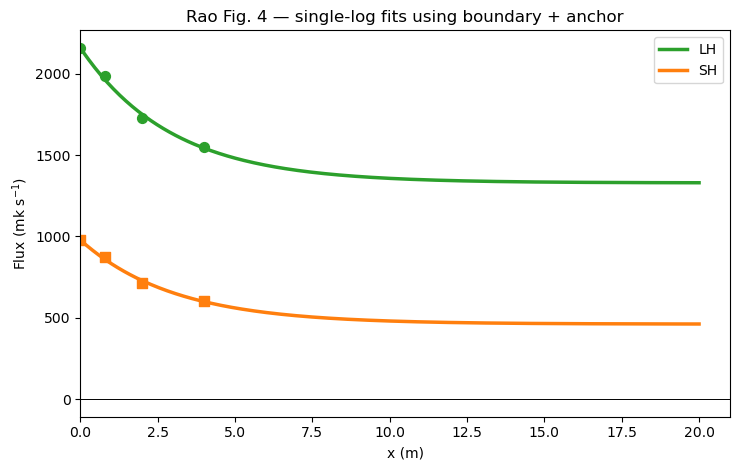

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import lstsq
from scipy.optimize import curve_fit
 
    
# -----------------  boundary + anchor points (edit if you read different values) -----------------
# x in meters; y in the figure’s flux units (“mk s^-1”)
x0, ySH0, yLH0 = 0.1,  -0.60,  1.00   # start (x=0)
xA, ySHA, yLHA = 2.0,  -0.20,  0.45   # 2 m
xB, ySHB, yLHB = 6.0,  -0.10,  0.4    # 6 m
xF, ySHF, yLHF = 20.0, -0.05,  0.36   # far downstream

_level = level  # use the solver-level value from the main configuration cell

x0, ySH0, yLH0 = p.x[0],  H_uniform_Wm2[0, _level],  LE_uniform_Wm2[0, _level]   # start (x=0)
xA, ySHA, yLHA = p.x[4], H_uniform_Wm2[4, _level],  LE_uniform_Wm2[4, _level]   # x=4
xB, ySHB, yLHB = p.x[10], H_uniform_Wm2[10, _level],  LE_uniform_Wm2[10, _level]   # x=10
xF, ySHF, yLHF = p.x[20], H_uniform_Wm2[20, _level],  LE_uniform_Wm2[20, _level]   # far downstream


# Choose a small positive shift so ln(x + x_shift) is defined at x=0.
x_shift = 0.001

x_pts   = np.array([x0, xA, xB, xF], float)
ySH_pts = np.array([ySH0, ySHA, ySHB, ySHF], float)
yLH_pts = np.array([yLH0, yLHA, yLHB, yLHF], float)

print(ySH_pts, )
def exp1(x, y_inf, L):
    # one-exponential with y0 fixed by the first point
    y0 = ySH0_or_yLH0 
    return y_inf + (y0 - y_inf) * np.exp(-x / L)

# Fit SH
ySH0_or_yLH0 = ySH0
p0_SH = (ySHF, 2.0)                              # initial guess: asymptote ~ far point
par_SH, _ = curve_fit(lambda x, y_inf, L: exp1(x, y_inf, L),
                      x_pts, ySH_pts, p0=p0_SH, maxfev=10000)
ySH_inf, L_SH = par_SH

# Fit LH
ySH0_or_yLH0 = yLH0
p0_LH = (yLHF, 2.0)
par_LH, _ = curve_fit(lambda x, y_inf, L: exp1(x, y_inf, L),
                      x_pts, yLH_pts, p0=p0_LH, maxfev=10000)
yLH_inf, L_LH = par_LH

# Evaluate fitted curves
_x_fit = np.linspace(0, 20, 300)
SH_fit = ySH_inf + (ySH0 - ySH_inf)*np.exp(-_x_fit/L_SH)
LH_fit = yLH_inf + (yLH0 - yLH_inf)*np.exp(-_x_fit/L_LH)

SH_range = ySH0 - ySH_inf 
LH_range = yLH0 - yLH_inf
print(f"SH(x) ≈ {ySH_inf:.2f} + ({SH_range:.2f}) * exp(-x/{L_SH:.2f})")
print(f"LH(x) ≈ {yLH_inf:.2f} + ({LH_range:.2f}) * exp(-x/{L_LH:.2f})")


# ----------------- 4) plot -----------------
plt.figure(figsize=(7.5, 4.8))
plt.plot(_x_fit,  LH_fit,  'C2', lw=2.5, label='LH')
plt.plot(_x_fit,  -SH_fit,  'C1', lw=2.5, label='SH')
plt.scatter(x_pts, yLH_pts, c='C2', s=50, marker='o', label='')
plt.scatter(x_pts, -ySH_pts, c='C1', s=50, marker='s', label='')
plt.axhline(0, color='k', lw=0.7)
plt.xlim(0, 21); 
# plt.ylim(-0.65, 1.1)
plt.xlabel('x (m)')
plt.ylabel('Flux (mk s$^{-1}$)')
plt.title('Rao Fig. 4 — single-log fits using boundary + anchor')
plt.legend()
plt.tight_layout()
plt.show()




### Appendix

In [ ]:
# density depends on air temperature
import numpy as np

# --- constants ---
cp  = 1005.0          # J kg^-1 K^-1  (specific heat at constant pressure)
R_d = 287.05          # J kg^-1 K^-1  (gas constant for dry air)
p_Pa = 101325.0       # Pa (set your measured station pressure if available)

def air_density(T_K, p_Pa=101325.0, q_kgkg=None):
    """
    Air density [kg m^-3] from temperature (K), pressure (Pa), and optional specific humidity q (kg/kg).
    Uses virtual temperature: T_v = T*(1 + 0.61 q) if q is provided.
    """
    if q_kgkg is not None:
        T_v = T_K * (1.0 + 0.61*q_kgkg)
    else:
        T_v = T_K
    return p_Pa / (R_d * T_v)

# If you already have ambient humidity as Q_a in g/kg, use it for moist-air density.
# Otherwise we'll compute a dry-air density.
try:
    q_a = Q_a / 1000.0   # g/kg -> kg/kg
except NameError:
    q_a = None

_T_a_K = p.T_a + 273.15  # use the value from the parameter object
rho = air_density(_T_a_K, p_Pa=p_Pa, q_kgkg=q_a)

# --- your original variables ---
zo = p.zom_f
_ustar_f = 0.15
_ustar_c = 0.15
k = p.k

# stability-neutral bulk transfer (ensure z_h > zo)
L = np.log(p.z[-1] / zo)      # dimensionless

# Use rho*cp instead of 1005*1.2
T_sc = _T_a_K + (p.H_c/(rho*cp)) * (1.0/(k*_ustar_c)) * L
print(T_sc - 273.15)

T_sf = _T_a_K + (p.H_f/(rho*cp)) * (1.0/(k*_ustar_f)) * L
print(T_sf - 273.15)

print(T_sf - T_sc)


-245.76845249424255
-238.99372619961494
6.774726294627609
